In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 13.5 MB/s eta 0:00:00
✓ Device: cuda
✓ All imports successful
✓ Configuration set
STEP 1 — Loading & Preparing Data
Loaded: 3,205 patients
GCS range: 3.0–15.0  mean=12.07  SD=3.18

Imputing (KNN)... done
✓ Features: 29 × 3,205 patients
✓ Train: 2,564  Test: 641

STEP 2 — Non-DL Models (Cross-Validation)

Running 5-fold CV on original GCS scale...

  Ridge... MAE=1.961 pts  R²=0.313
  Random Forest... MAE=1.706 pts  R²=0.499
  XGBoost... MAE=1.665 pts  R²=0.505

Tuning Non-DL models (Optuna, 50 trials each)...

  [1/3] Ridge Regression (grid over alpha)...
    ✓ Best alpha=10.0  MAE=1.9612 pts

  [2/3] Random Forest (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

    ✓ Best RF MAE: 1.6984 pts
      Params: {'n_estimators': 544, 'max_depth': 14, 'min_samples_split': 6, 'min_samples_leaf': 3, 'max_features': 0.5}

  [3/3] XGBoost (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]

    ✓ Best XGB MAE: 1.6262 pts
      Params: {'n_estimators': 514, 'learning_rate': 0.016041494398154103, 'max_depth': 9, 'subsample': 0.6048295404049171, 'colsample_bytree': 0.9011797507798667, 'reg_alpha': 0.04990632198778348, 'reg_lambda': 3.9451022594325407, 'min_child_weight': 5}

Training final non-DL models with tuned hyperparameters...
  ✓ Ridge
  ✓ Random Forest
  ✓ XGBoost

Non-DL tuning complete.
  Ridge best alpha:       10.0
  RF    best n_estimators: 544, max_depth: 14
  XGB   best lr:           0.0160, max_depth: 9, n_estimators: 514

STEP 3 — DL Model Definitions
✓ MLP Regressor defined
✓ 1D CNN Regressor defined
✓ TabNet Regressor will be initialised during training

STEP 4 — DL Models (Cross-Validation)

  MLP:
    Fold 1: MAE=1.727 pts  R²=0.451
    Fold 2: MAE=1.813 pts  R²=0.459
    Fold 3: MAE=1.622 pts  R²=0.459
    Fold 4: MAE=1.740 pts  R²=0.505
    Fold 5: MAE=1.592 pts  R²=0.555
  → Mean: MAE=1.699±0.081  R²=0.486±0.040

  1D CNN:
    Fold 1: MAE=1.800 pts  R

...

  ✓ Best MLP MAE: 1.6869 GCS pts
    Params: {'h1': 256, 'h2': 256, 'h3': 128, 'dropout': 0.11375540844608736, 'lr': 0.006586289317583112}

[2/3] Tuning 1D CNN...


  0%|          | 0/50 [00:00<?, ?it/s]

  ✓ Best CNN MAE: 1.7066 GCS pts
    Params: {'filters1': 128, 'filters2': 256, 'dense': 256, 'dropout': 0.191519266196649, 'lr': 0.00014254757044027455}

[3/3] Tuning TabNet...


  0%|          | 0/50 [00:00<?, ?it/s]


Early stopping occurred at epoch 34 with best_epoch = 24 and best_val_0_mae = 0.55788

Early stopping occurred at epoch 25 with best_epoch = 15 and best_val_0_mae = 0.60374

Early stopping occurred at epoch 58 with best_epoch = 48 and best_val_0_mae = 0.62179

Early stopping occurred at epoch 24 with best_epoch = 14 and best_val_0_mae = 0.60536
Stop training because you reached max_epochs = 60 with best_epoch = 56 and best_val_0_mae = 0.66454

Early stopping occurred at epoch 31 with best_epoch = 21 and best_val_0_mae = 0.61738

Early stopping occurred at epoch 28 with best_epoch = 18 and best_val_0_mae = 0.58698

Early stopping occurred at epoch 27 with best_epoch = 17 and best_val_0_mae = 0.56357
Stop training because you reached max_epochs = 60 with best_epoch = 54 and best_val_0_mae = 0.53624

Early stopping occurred at epoch 50 with best_epoch = 40 and best_val_0_mae = 0.56005

Early stopping occurred at epoch 47 with best_epoch = 37 and best_val_0_mae = 0.562

Early stopping occ

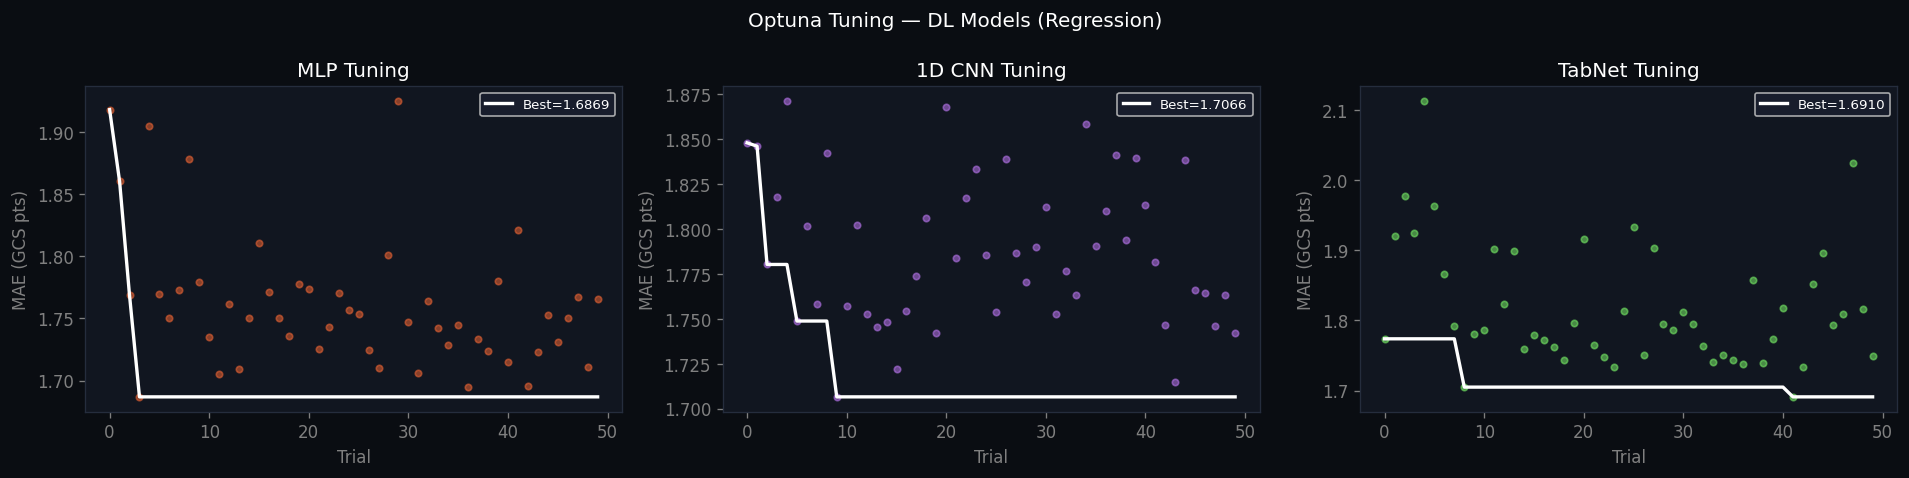


Tuning Summary:
  MLP    best MAE: 1.6869 pts  → hidden=[256, 256, 128], dropout=0.114, lr=0.00659
  CNN    best MAE: 1.7066 pts  → filters=(128,256), dense=256, dropout=0.192
  TabNet best MAE: 1.6910 pts  → n_d=16, n_steps=3, gamma=1.104

STEP 6 — Final Evaluation on Test Set (Tuned Models)

Training tuned MLP... done
Training tuned CNN... done
Training tuned TabNet... 
Early stopping occurred at epoch 49 with best_epoch = 34 and best_val_0_mae = 0.53352
done

Model                     MAE (pts)       R²     RMSE  Type
──────────────────────────────────────────────────────────
Ridge                        1.9819   0.3534   2.5551  Non-DL
Random Forest                1.7138   0.4990   2.2491  Non-DL
XGBoost                      1.6441   0.5138   2.2155  Non-DL
MLP                          1.6959   0.4733   2.3060  DL    
1D CNN                       1.6800   0.4910   2.2669  DL    
TabNet                       1.6963   0.4149   2.4305  DL    

✓ Best model (lowest MAE): XGBoost (MAE=

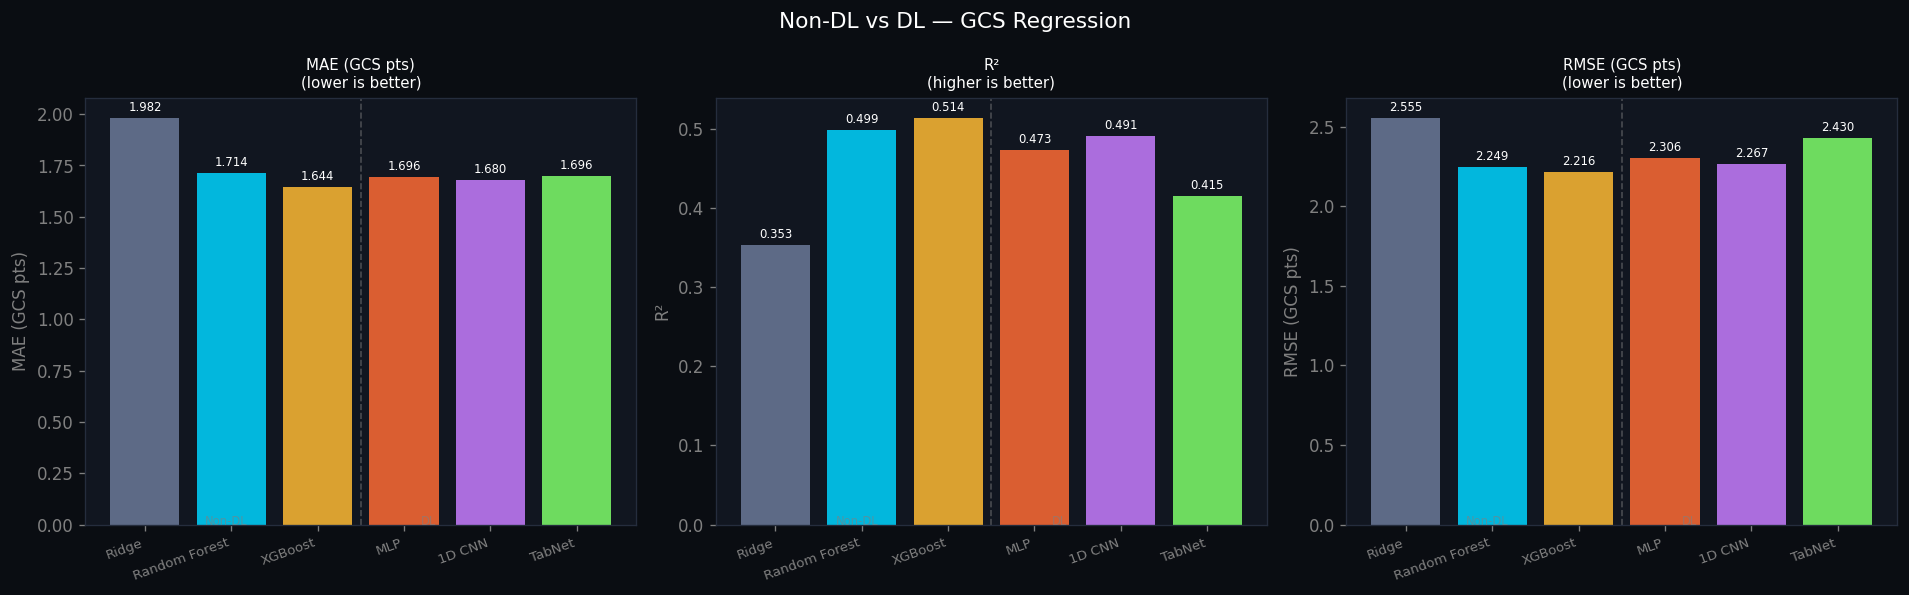


────────────────────────────────────────────────────────────
  CV Comparison
────────────────────────────────────────────────────────────


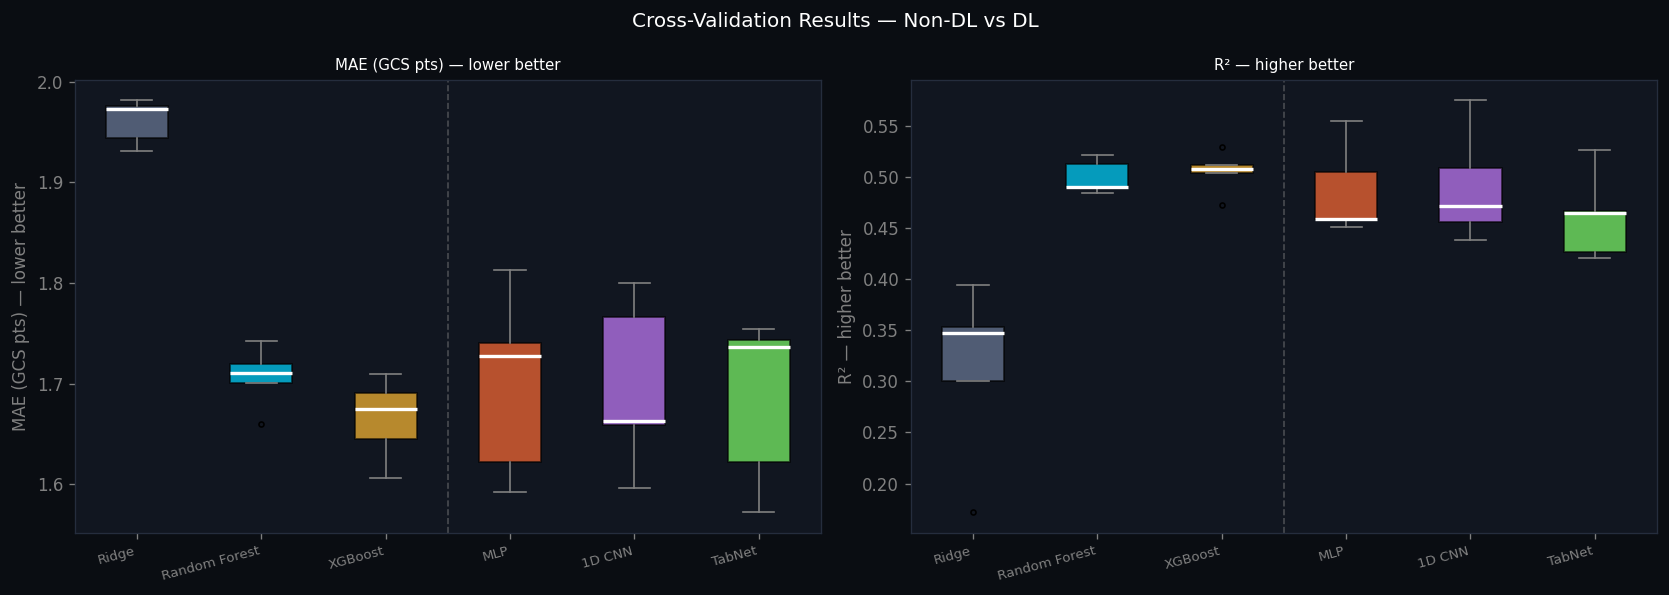


────────────────────────────────────────────────────────────
  Predicted vs Actual
────────────────────────────────────────────────────────────


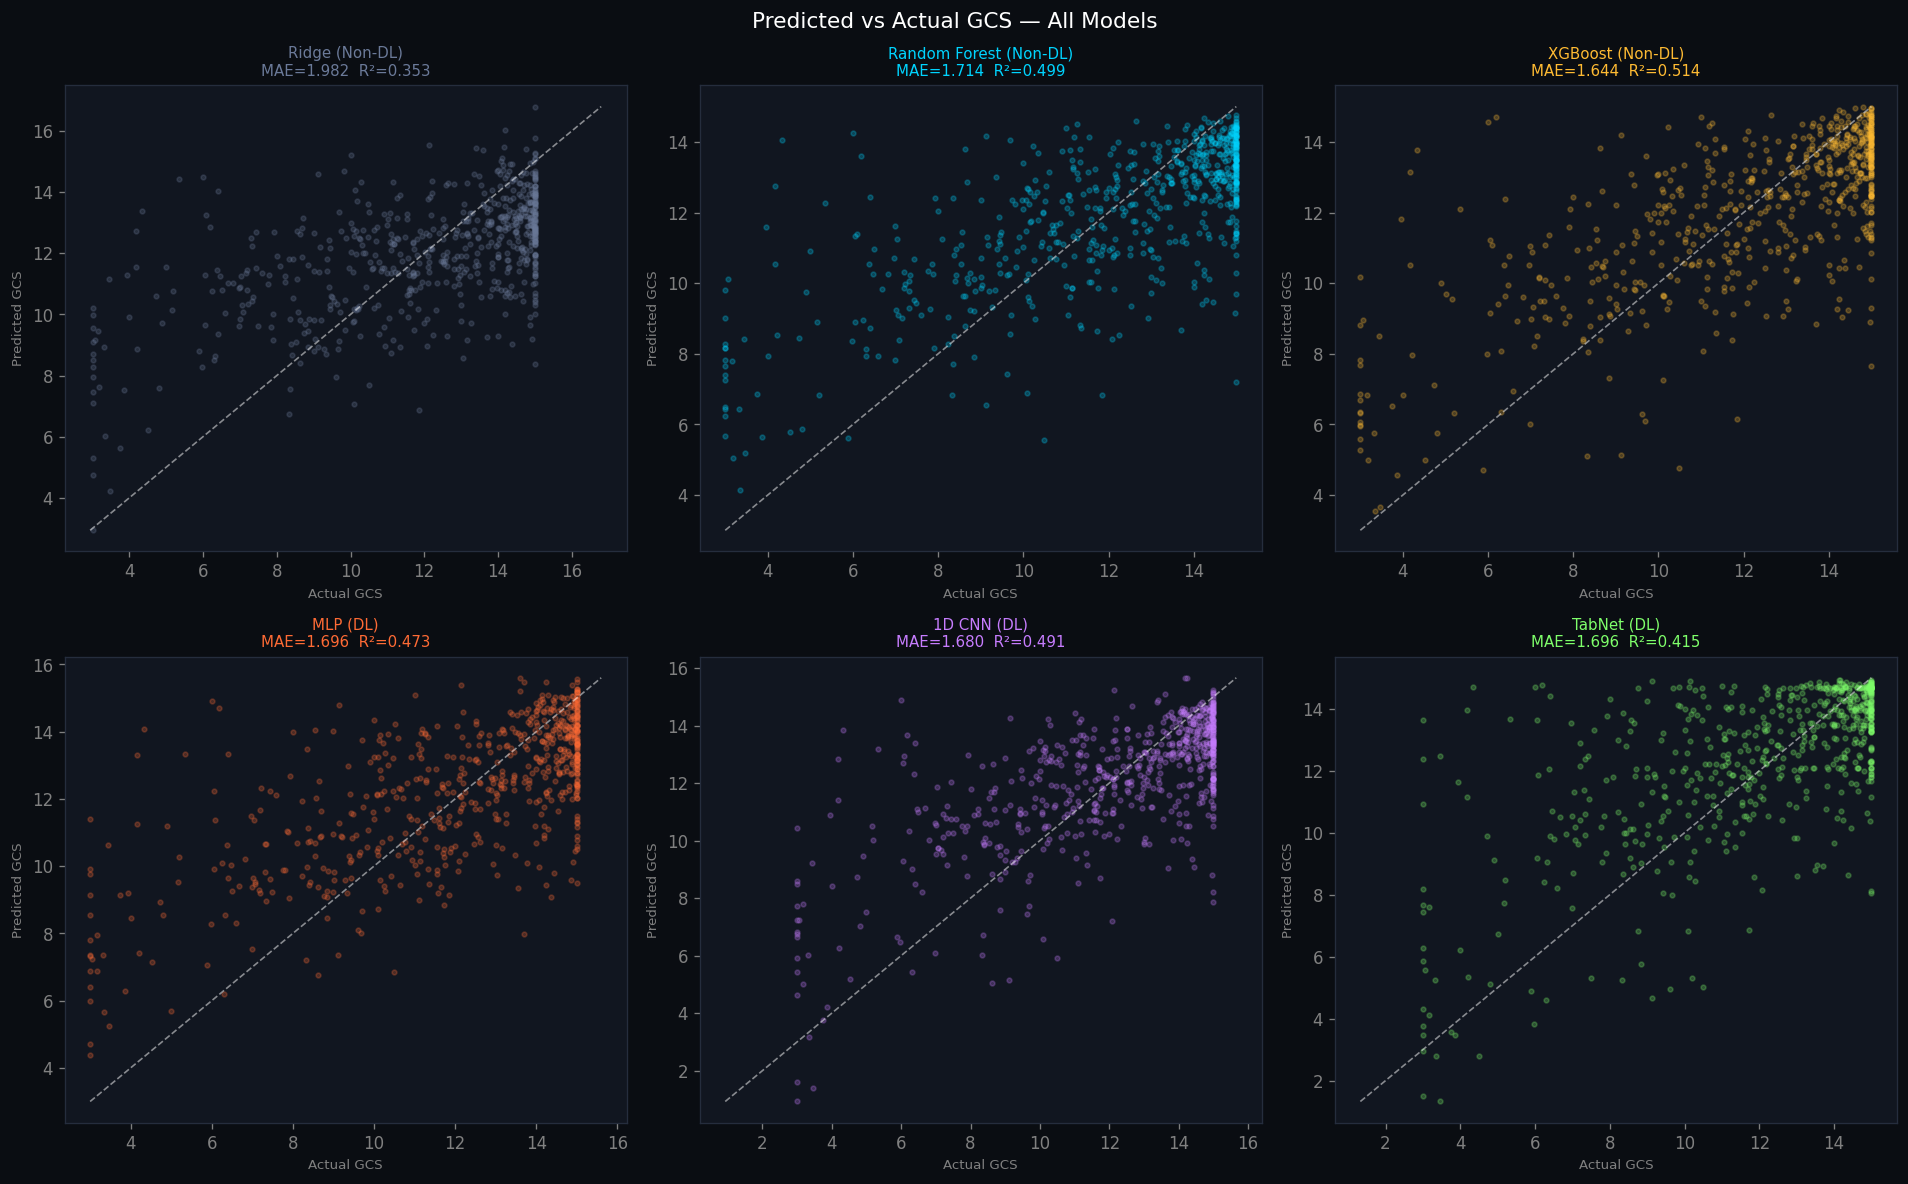


────────────────────────────────────────────────────────────
  Residual Distributions
────────────────────────────────────────────────────────────


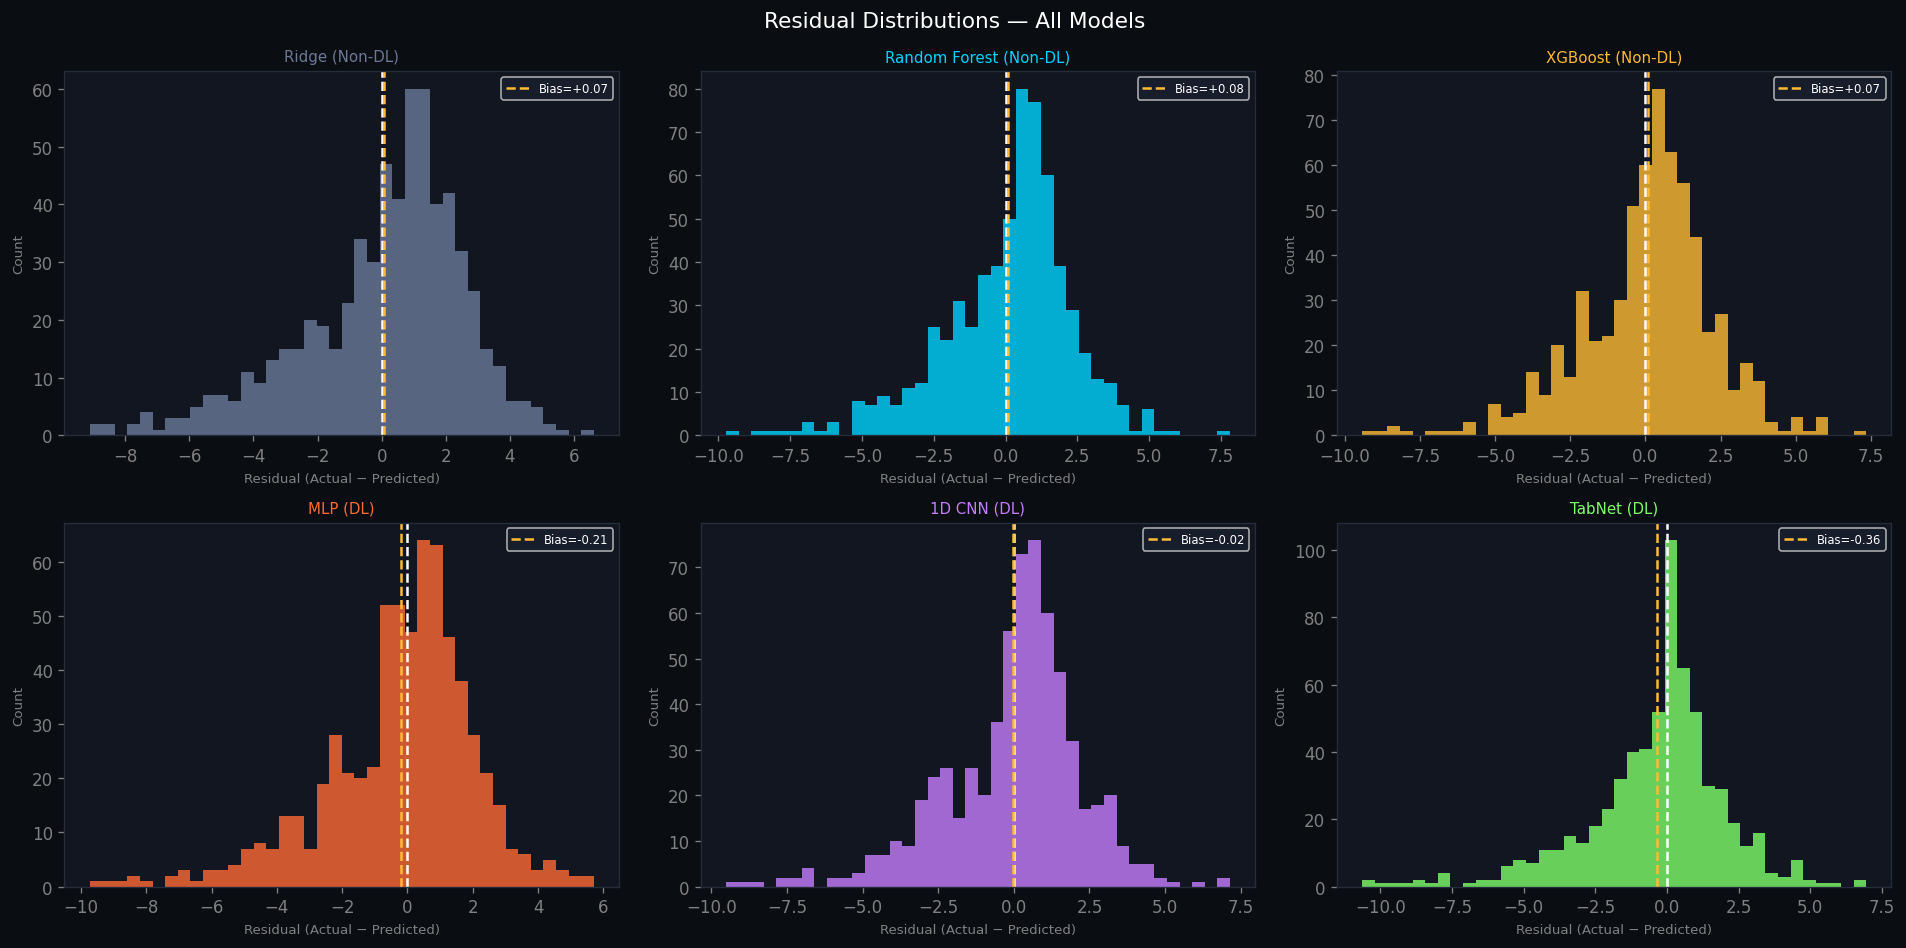


────────────────────────────────────────────────────────────
  Error by GCS Band
────────────────────────────────────────────────────────────


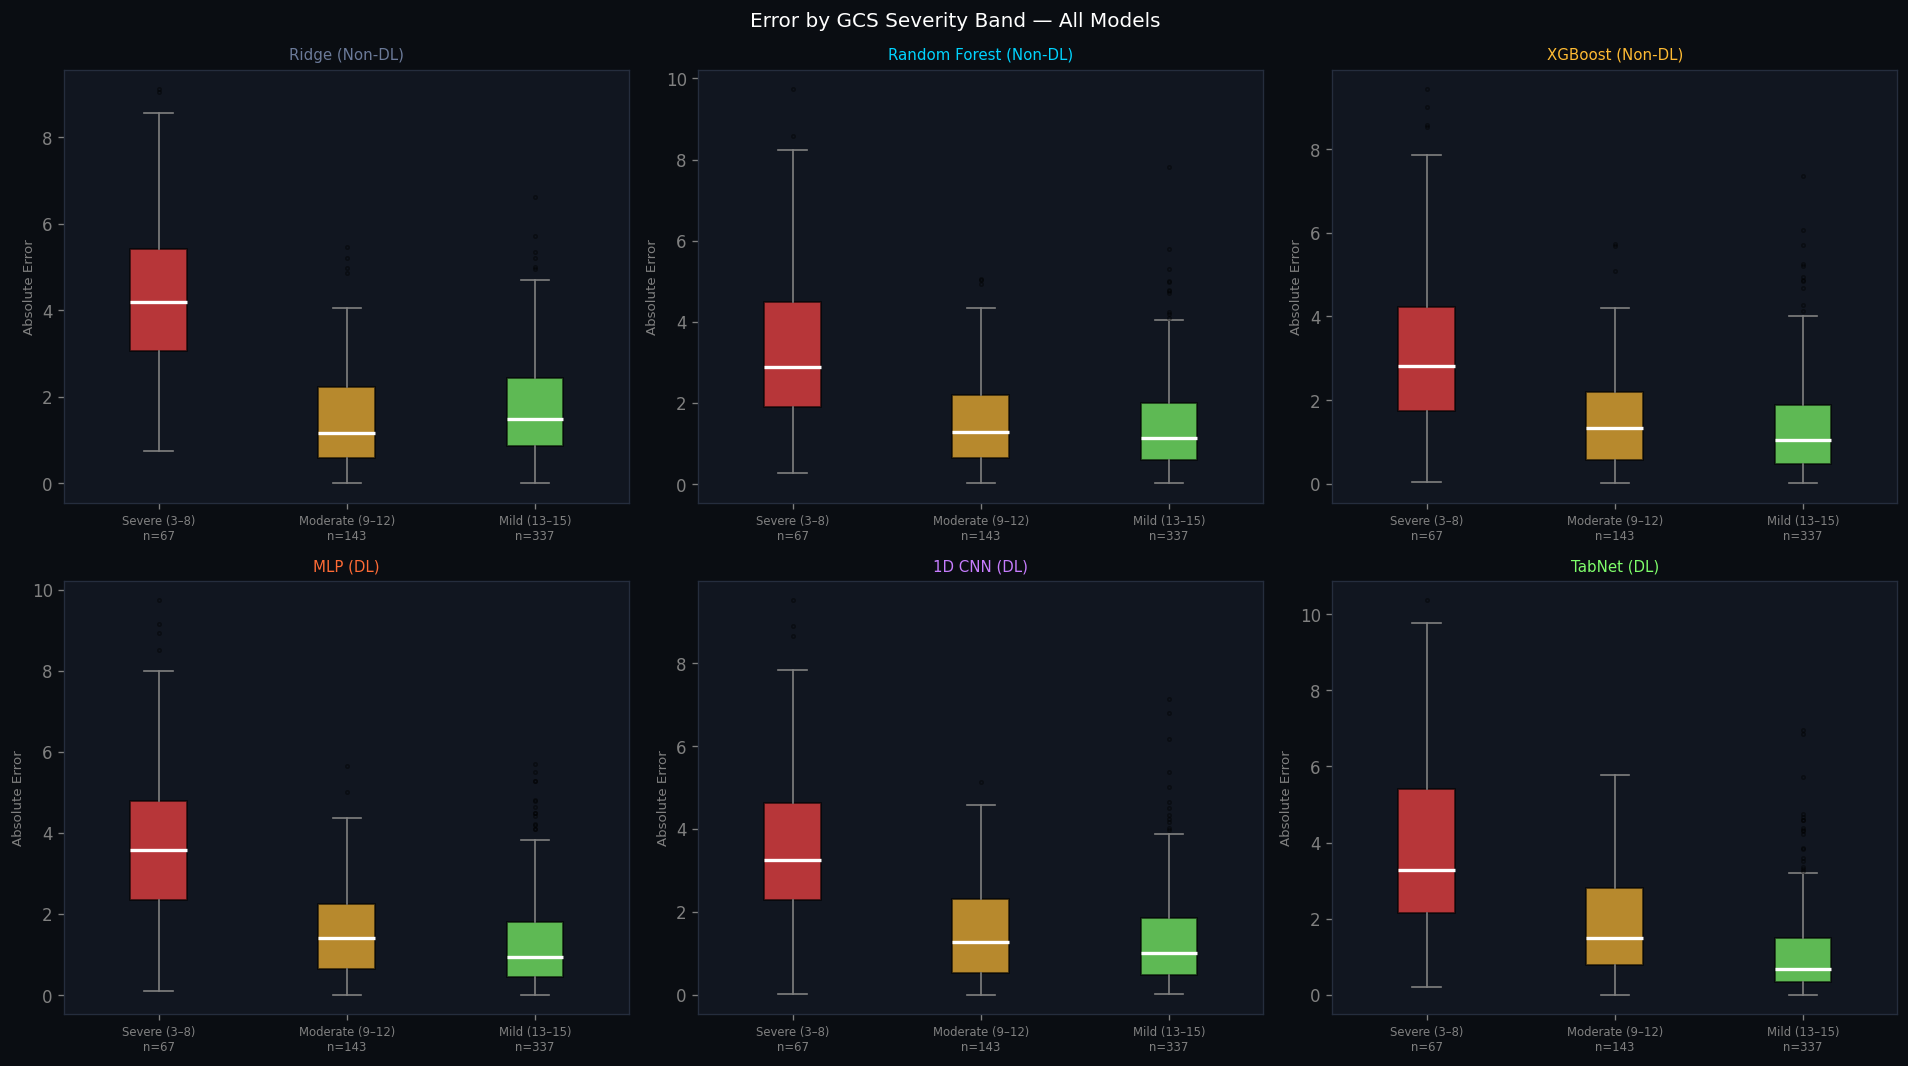


────────────────────────────────────────────────────────────
  Cumulative Error Curve
────────────────────────────────────────────────────────────


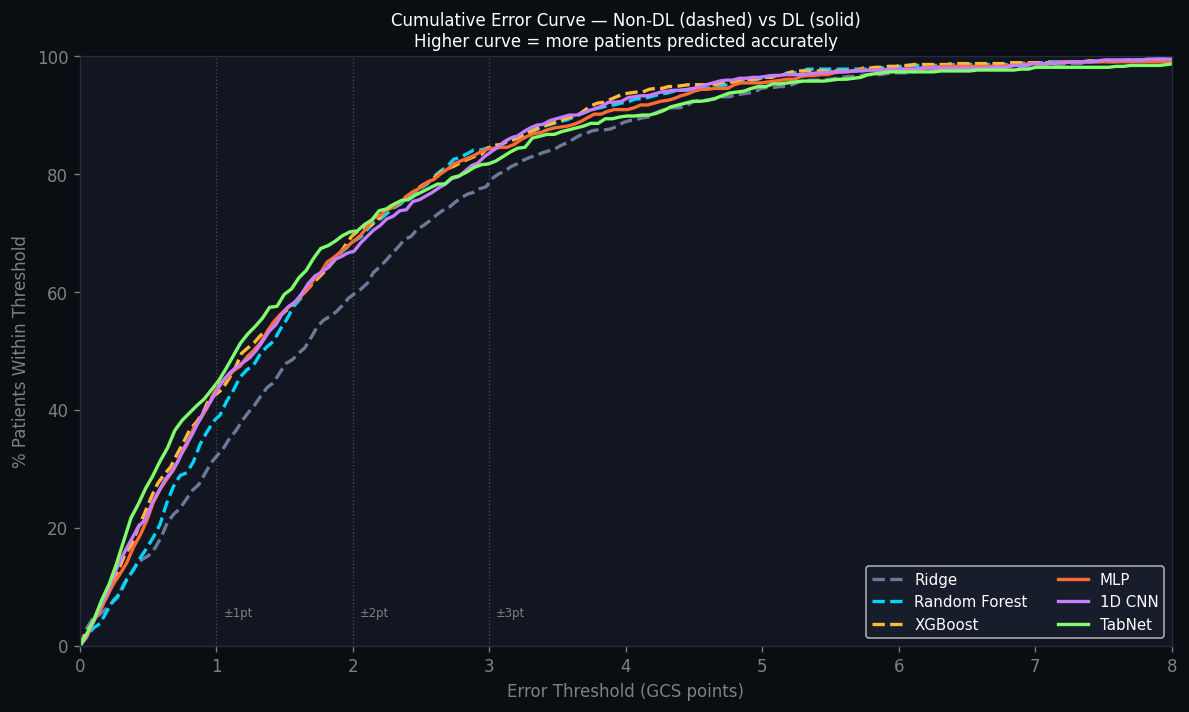


────────────────────────────────────────────────────────────
  DL Training Curves
────────────────────────────────────────────────────────────


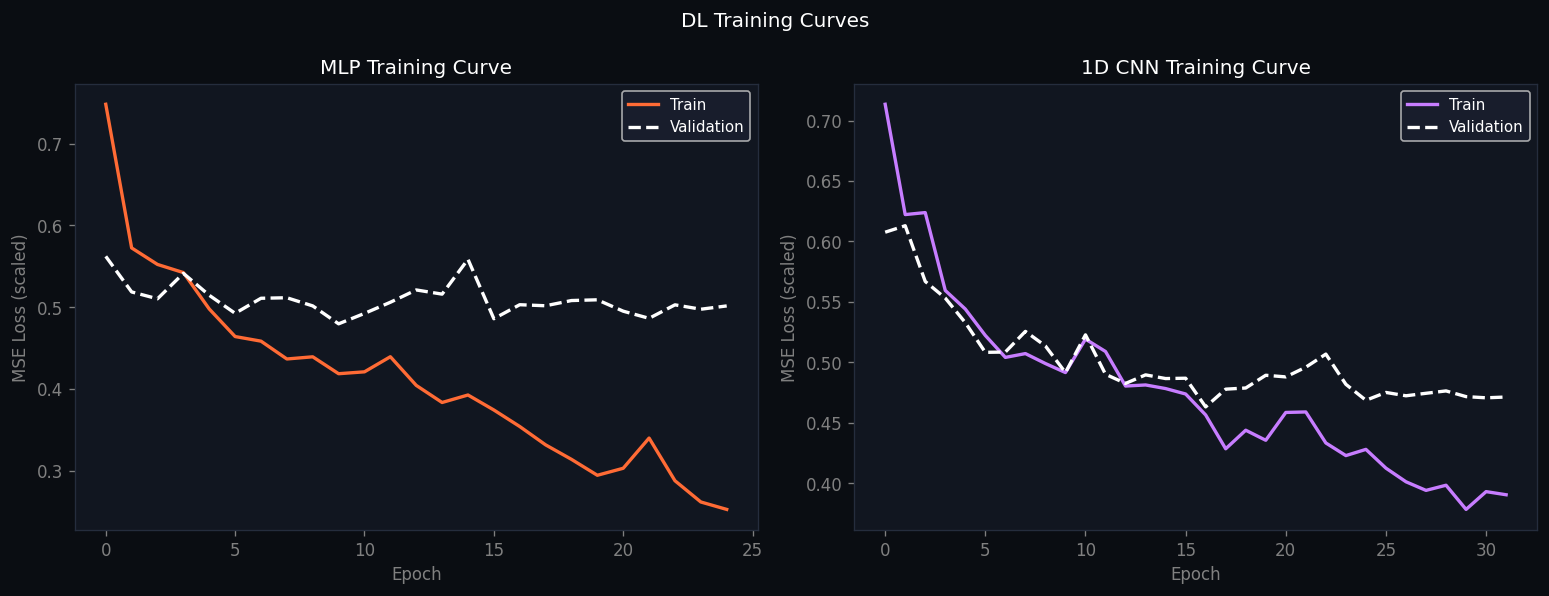


────────────────────────────────────────────────────────────
  SHAP Importance
────────────────────────────────────────────────────────────


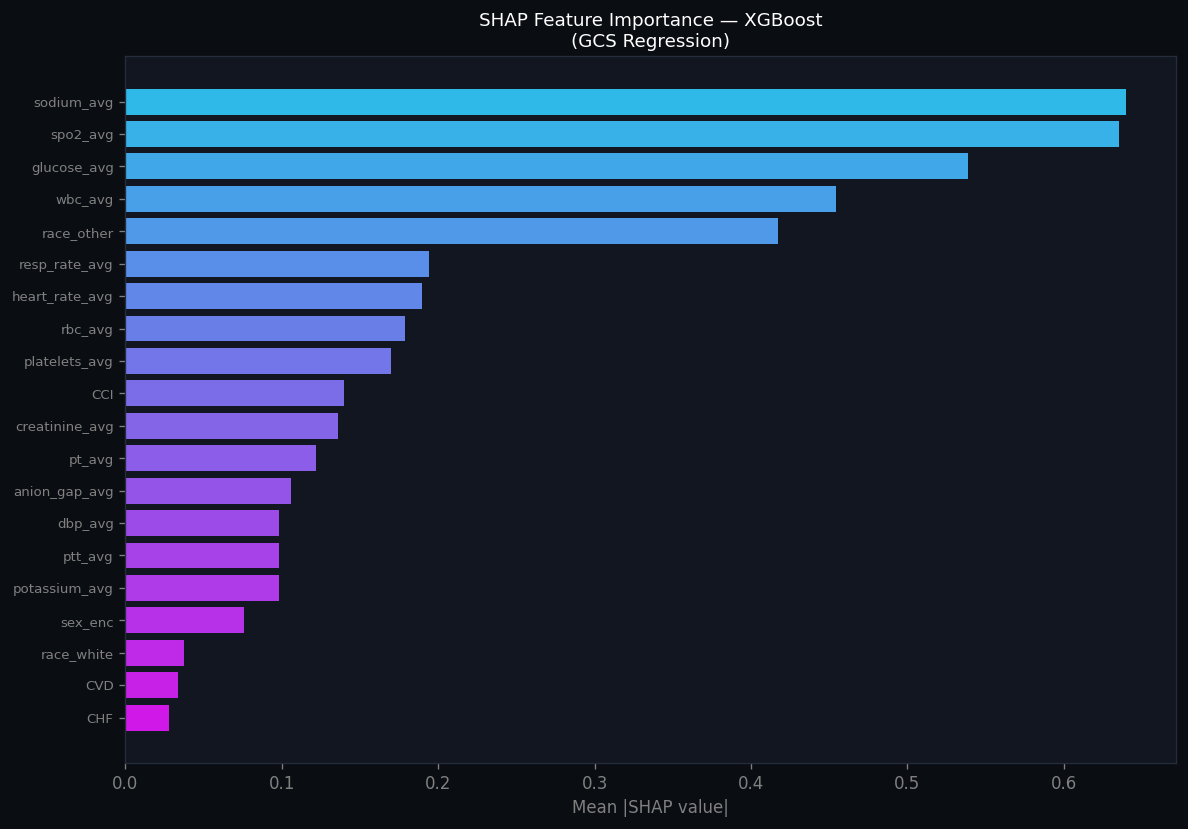


FINAL SUMMARY — GCS Regression

Model                     MAE (pts)       R²     RMSE  Type
──────────────────────────────────────────────────────────
Ridge                        1.9819   0.3534   2.5551  Non-DL
Random Forest                1.7138   0.4990   2.2491  Non-DL
XGBoost                      1.6441   0.5138   2.2155  Non-DL
MLP                          1.6959   0.4733   2.3060  DL    
1D CNN                       1.6800   0.4910   2.2669  DL    
TabNet                       1.6963   0.4149   2.4305  DL    

✓ Best overall: XGBoost
  MAE  = 1.6441 GCS points
  R²   = 0.5138
  RMSE = 2.2155 GCS points

Within-threshold accuracy (test set):
  ±1 GCS point(s):  Ridge=32.1%  Random Forest=38.5%  XGBoost=42.6%  MLP=43.7%  1D CNN=43.2%  TabNet=44.5%
  ±2 GCS point(s):  Ridge=59.6%  Random Forest=68.6%  XGBoost=69.4%  MLP=68.5%  1D CNN=66.9%  TabNet=70.2%
  ±3 GCS point(s):  Ridge=78.5%  Random Forest=84.4%  XGBoost=84.7%  MLP=84.2%  1D CNN=83.5%  TabNet=81.7%

How to read the plot

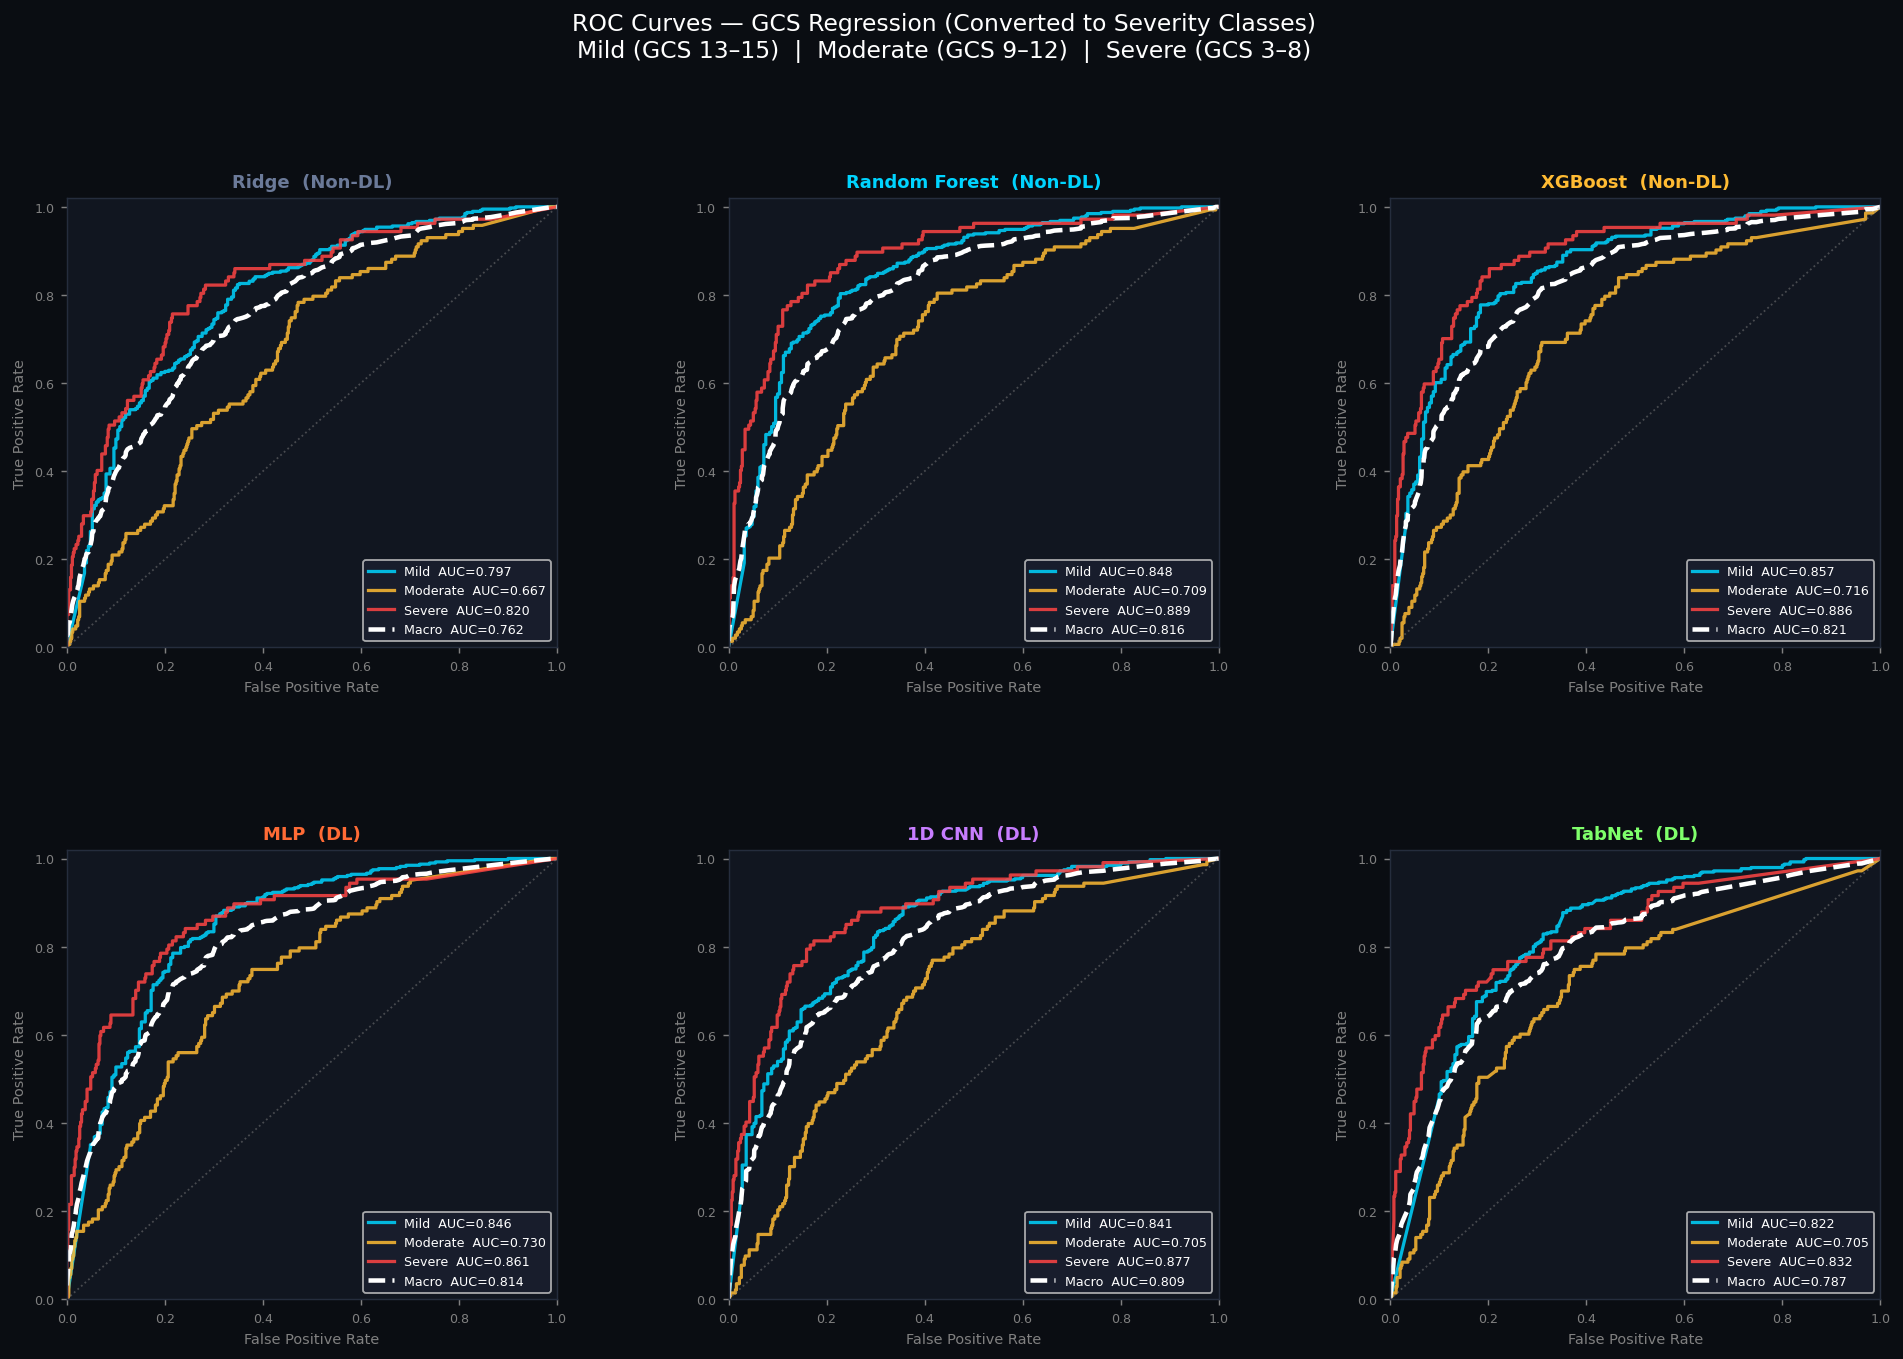

✓ Saved: roc_reg_all_macro.png


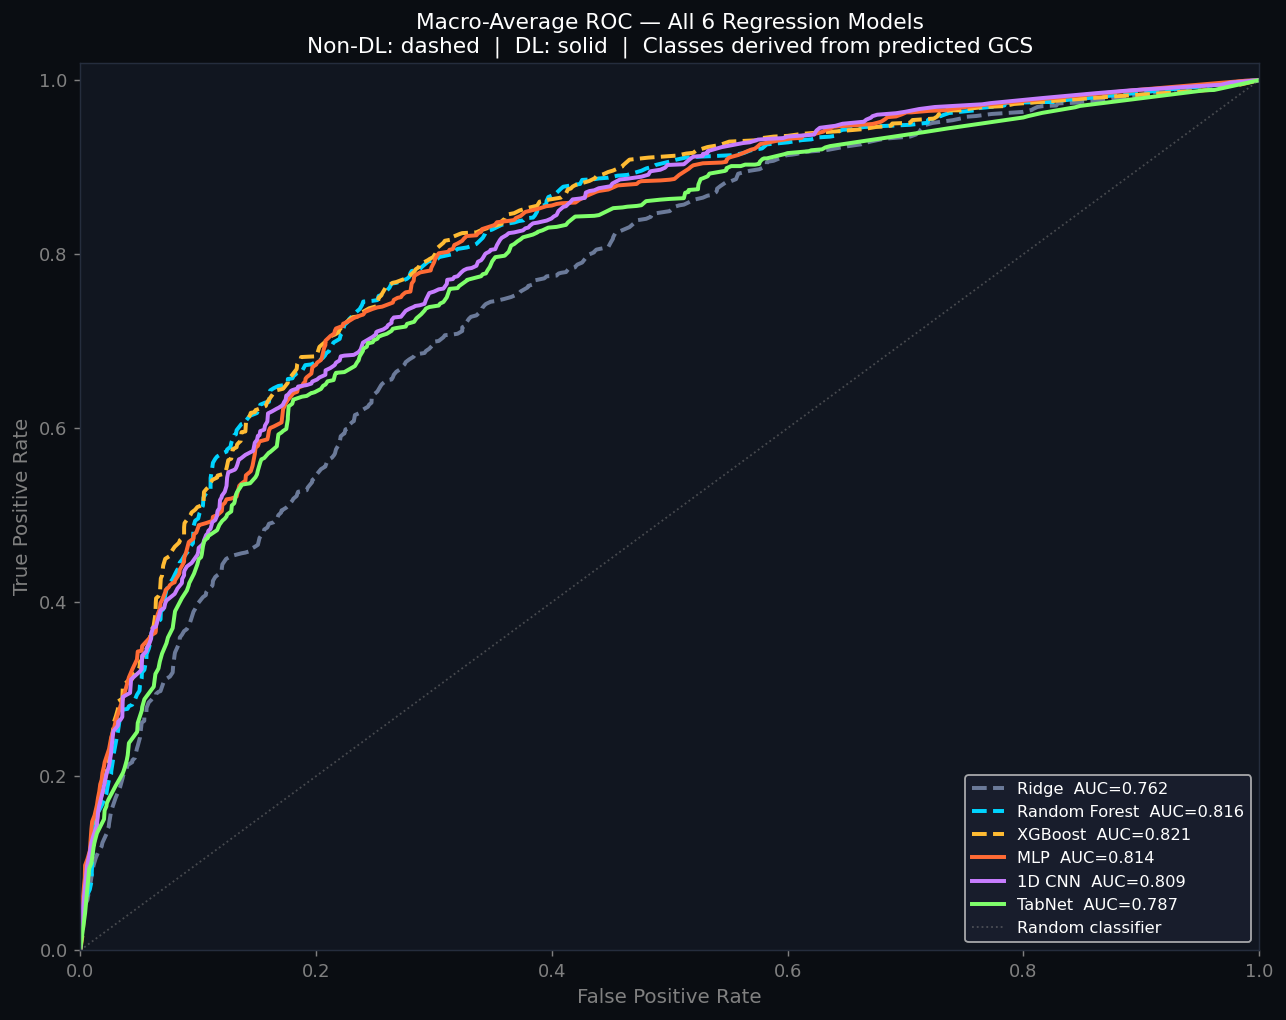

✓ Saved: roc_reg_per_class.png


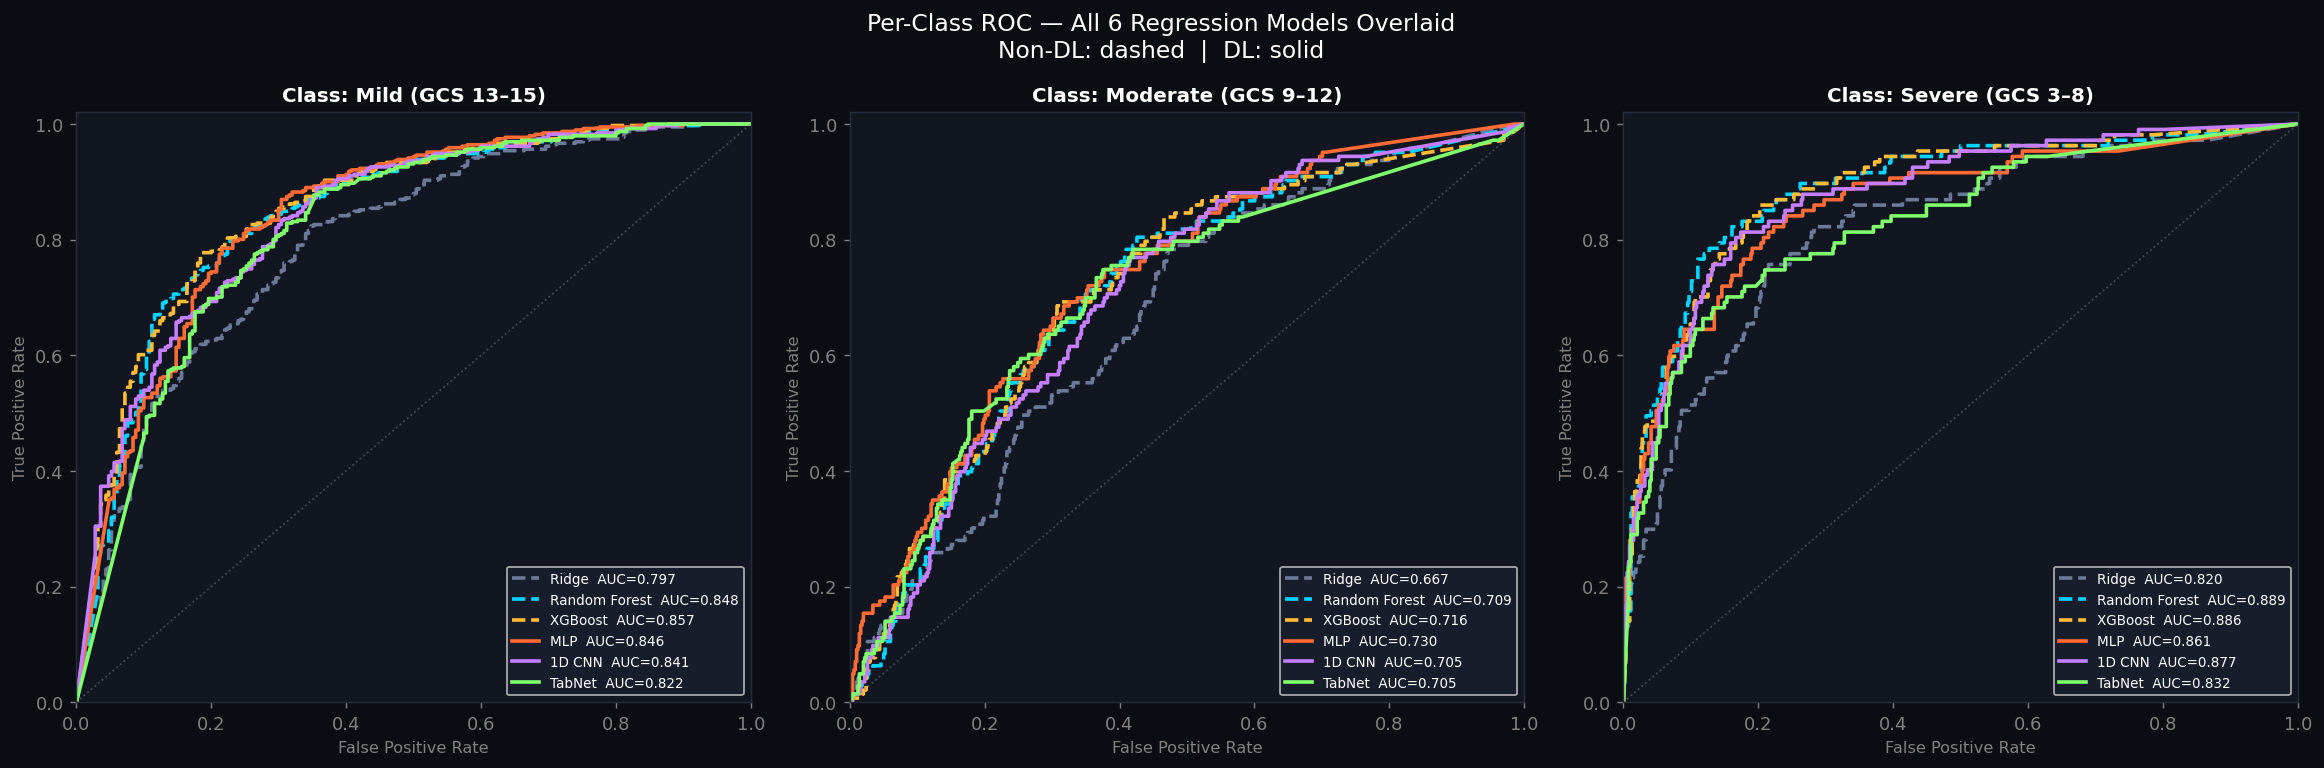


Model                        Mild   Moderate   Severe    Macro  Type
────────────────────────────────────────────────────────────────────
Ridge                      0.7969     0.6673   0.8195   0.7625  Non-DL
Random Forest              0.8476     0.7087   0.8892   0.8164  Non-DL
XGBoost                    0.8569     0.7156   0.8865   0.8209  Non-DL
MLP                        0.8458     0.7299   0.8614   0.8135  DL    
1D CNN                     0.8413     0.7051   0.8775   0.8092  DL    
TabNet                     0.8221     0.7054   0.8317   0.7875  DL    

ROC output files:
  roc_reg_individual.png  — 2×3 grid: per-class + macro per model
  roc_reg_all_macro.png   — all 6 macro curves overlaid (use in paper)
  roc_reg_per_class.png   — 3 panels: one per class, all models

Method note: Continuous GCS predictions converted to severity class
probabilities using distance-based softmax over class centroids
(Mild=14, Moderate=10.5, Severe=5.5). This measures how well the
regression model 

In [1]:
# ============================================================
# GCS SCORE REGRESSION — COMBINED PIPELINE
# Non-DL: Ridge, Random Forest, XGBoost
# DL:     MLP, 1D CNN, TabNet
# Predicts: gcs_total_avg (continuous score 3–15)
# Google Colab Ready
# ============================================================


# ────────────────────────────────────────────────────────────
# CELL 1 — Install dependencies
# ────────────────────────────────────────────────────────────

!pip install pytorch-tabnet xgboost shap optuna --quiet



# ────────────────────────────────────────────────────────────
# CELL 2 — Upload data
# ────────────────────────────────────────────────────────────
"""
from google.colab import files
uploaded = files.upload()   # select TBi_3205_Allfeature.csv
"""


# ────────────────────────────────────────────────────────────
# CELL 3 — Imports
# ────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from pytorch_tabnet.tab_model import TabNetRegressor

import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.pipeline import Pipeline

import shap
from IPython.display import display, Image
import os

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {DEVICE}")
print("✓ All imports successful")


# ────────────────────────────────────────────────────────────
# CELL 4 — Configuration
# ────────────────────────────────────────────────────────────

DATA_FILE   = "TBi_3205_Allfeature.csv"
TARGET_COL  = "gcs_total_avg"
RANDOM_SEED = 42
N_FOLDS     = 5
EPOCHS      = 100
PATIENCE    = 15
BATCH_SIZE  = 64

# All GCS columns excluded — predicting gcs_avg,
# cannot use gcs_min or gcs_max as features (leakage)
GCS_COLS = [ "gcs_total_avg"]

COMORBIDITY_COLS = ["CHF", "liver", "chronic_lung_disease", "CVD",
                    "malignant", "AKI", "CCI"]
VITAL_COLS = [
    "heart_rate_avg",
    "resp_rate_avg",
    "dbp_avg",
    "spo2_avg",
]
LAB_COLS = [
        "wbc_avg",
    "creatinine_avg",
     "glucose_avg",
    "platelets_avg",
   "anion_gap_avg",
     "sodium_avg",
     "potassium_avg",
        "rbc_avg",
]
COAG_COLS     = ["pt_avg",
                  "ptt_avg"]
##SEVERITY_COLS = ["apsiii", "sofa"] ##  # oasis and sapsii removed

MODEL_COLORS = {
    "Ridge":         "#6b7a99",
    "Random Forest": "#00d4ff",
    "XGBoost":       "#ffbb33",
    "MLP":           "#ff6b35",
    "1D CNN":        "#c77dff",
    "TabNet":        "#7fff6b",
}

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print("✓ Configuration set")


# ────────────────────────────────────────────────────────────
# CELL 5 — Load & prepare data
# ────────────────────────────────────────────────────────────
# Steps:
#   1. Load CSV, drop rows with missing GCS target
#   2. Encode sex and race
#   3. Add PT/PTT missingness flags
#   4. KNN impute remaining missing values
#   5. Scale features (zero mean, unit variance)
#   6. Scale target GCS — helps DL convergence
#      (inverse-transformed back for all reported metrics)
#   7. Train/test split 80/20

print("=" * 60)
print("STEP 1 — Loading & Preparing Data")
print("=" * 60)

df = pd.read_csv(DATA_FILE)
df = df[df[TARGET_COL].notna()].copy()
print(f"Loaded: {df.shape[0]:,} patients")
print(f"GCS range: {df[TARGET_COL].min():.1f}–{df[TARGET_COL].max():.1f}  "
      f"mean={df[TARGET_COL].mean():.2f}  SD={df[TARGET_COL].std():.2f}")

df["sex_enc"] = (df["sex"] == "M").astype(int)

def encode_race(r):
    if pd.isna(r): return "unknown"
    r = str(r).upper()
    if "WHITE"    in r: return "white"
    if "BLACK"    in r: return "black"
    if "HISPANIC" in r: return "hispanic"
    if "ASIAN"    in r: return "asian"
    return "other"

df["race_grp"] = df["race"].apply(encode_race)
race_dummies   = pd.get_dummies(df["race_grp"], prefix="race", drop_first=True)
df             = pd.concat([df, race_dummies], axis=1)
RACE_COLS      = race_dummies.columns.tolist()

COAG_FLAGS = []
for col in COAG_COLS:
    flag = f"{col}_missing"
    df[flag] = df[col].isna().astype(int)
    COAG_FLAGS.append(flag)

ALL_FEATURES = (COMORBIDITY_COLS + VITAL_COLS + LAB_COLS +
                COAG_COLS + COAG_FLAGS +
                ["sex_enc", "MST"] + RACE_COLS)
ALL_FEATURES = [c for c in ALL_FEATURES
                if c in df.columns and c not in GCS_COLS]

X_raw = df[ALL_FEATURES].copy()
y     = df[TARGET_COL].values.astype(np.float32)

keep  = X_raw.columns[X_raw.isnull().mean() < 0.5]
X_raw = X_raw[keep].copy()

print("\nImputing (KNN)...", end=" ")
imputer  = KNNImputer(n_neighbors=5)
X_imp    = imputer.fit_transform(X_raw)
X_imp    = pd.DataFrame(X_imp, columns=X_raw.columns)
print("done")

# Scale features
feature_scaler = StandardScaler()
X_scaled       = feature_scaler.fit_transform(X_imp).astype(np.float32)

# Scale target — DL models converge better on normalised targets
# All metrics are reported in original GCS scale after inversion
target_scaler  = StandardScaler()
y_scaled       = target_scaler.fit_transform(
    y.reshape(-1, 1)).ravel().astype(np.float32)

feature_names = X_raw.columns.tolist()
N_FEATURES    = X_scaled.shape[1]

print(f"✓ Features: {N_FEATURES} × {X_scaled.shape[0]:,} patients")

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=RANDOM_SEED
)
# Original-scale test labels for metric reporting
y_test_orig = target_scaler.inverse_transform(
    y_test.reshape(-1, 1)).ravel()
y_train_orig = target_scaler.inverse_transform(
    y_train.reshape(-1, 1)).ravel()

print(f"✓ Train: {len(X_train):,}  Test: {len(X_test):,}")


# ────────────────────────────────────────────────────────────
# CELL 6 — Non-DL Models
# ────────────────────────────────────────────────────────────
# Ridge Regression — linear baseline
# Random Forest    — ensemble of decision trees
# XGBoost          — gradient boosted trees
# All trained with 5-fold cross-validation.
# Metrics: MAE (avg error in GCS points), R² (variance explained)

print("\n" + "=" * 60)
print("STEP 2 — Non-DL Models (Cross-Validation)")
print("=" * 60)

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

scoring = {
    "R²":   "r2",
    "MAE":  "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
}

# Non-DL models use unscaled target (original GCS) — no need for inversion
y_orig = target_scaler.inverse_transform(
    y_scaled.reshape(-1, 1)).ravel()
X_all  = X_scaled

non_dl_models = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("reg",    Ridge(alpha=1.0)),
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, random_state=RANDOM_SEED, n_jobs=-1
    ),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        tree_method="hist", random_state=RANDOM_SEED, verbosity=0
    ),
}

non_dl_cv = {}
print(f"\nRunning {N_FOLDS}-fold CV on original GCS scale...\n")

for name, model in non_dl_models.items():
    print(f"  {name}...", end=" ", flush=True)
    res = cross_validate(model, X_all, y_orig,
                          cv=kf, scoring=scoring, n_jobs=-1)
    non_dl_cv[name] = res
    mae  = -res["test_MAE"].mean()
    r2   =  res["test_R²"].mean()
    print(f"MAE={mae:.3f} pts  R²={r2:.3f}")

# ────────────────────────────────────────────────────────────
# CELL 6b — Non-DL Hyperparameter Tuning (Optuna)
# ────────────────────────────────────────────────────────────
# Tunes Ridge, Random Forest, and XGBoost using Bayesian
# optimisation. Objective: minimise MAE on 5-fold CV
# (reported in original GCS scale, range 3–15).

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("\nTuning Non-DL models (Optuna, 50 trials each)...")

# ── Ridge — grid over alpha ───────────────────────────────────
print("\n  [1/3] Ridge Regression (grid over alpha)...")
from sklearn.model_selection import cross_val_score

best_ridge_alpha = 1.0
best_ridge_mae   = np.inf
for alpha in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("reg",    Ridge(alpha=alpha)),
    ])
    maes = -cross_val_score(
        pipe, X_all, y_orig, cv=kf,
        scoring="neg_mean_absolute_error", n_jobs=-1)
    if maes.mean() < best_ridge_mae:
        best_ridge_mae   = maes.mean()
        best_ridge_alpha = alpha

print(f"    ✓ Best alpha={best_ridge_alpha}  MAE={best_ridge_mae:.4f} pts")

# ── Random Forest Tuning ──────────────────────────────────────
print("\n  [2/3] Random Forest (50 trials)...")

def rf_reg_objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators",   100, 600),
        "max_depth":         trial.suggest_int("max_depth",       3, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf",  1, 10),
        "max_features":      trial.suggest_categorical(
                                 "max_features", ["sqrt", "log2", 0.5]),
    }
    model = RandomForestRegressor(
        **params, random_state=RANDOM_SEED, n_jobs=-1
    )
    maes = -cross_val_score(
        model, X_train, y_train_orig, cv=kf,
        scoring="neg_mean_absolute_error", n_jobs=-1)
    return maes.mean()

rf_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
rf_study.optimize(rf_reg_objective, n_trials=50, show_progress_bar=True)
best_rf_params = rf_study.best_params
print(f"    ✓ Best RF MAE: {rf_study.best_value:.4f} pts")
print(f"      Params: {best_rf_params}")

# ── XGBoost Tuning ────────────────────────────────────────────
print("\n  [3/3] XGBoost (50 trials)...")

def xgb_reg_objective(trial):
    params = {
        "n_estimators":     trial.suggest_int("n_estimators",   100, 600),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth":        trial.suggest_int("max_depth",       3, 10),
        "subsample":        trial.suggest_float("subsample",     0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha",     1e-4, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda",    1e-4, 10.0, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
    }
    model = xgb.XGBRegressor(
        **params, tree_method="hist",
        random_state=RANDOM_SEED, verbosity=0
    )
    maes = -cross_val_score(
        model, X_train, y_train_orig, cv=kf,
        scoring="neg_mean_absolute_error", n_jobs=-1)
    return maes.mean()

xgb_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
xgb_study.optimize(xgb_reg_objective, n_trials=50, show_progress_bar=True)
best_xgb_params = xgb_study.best_params
print(f"    ✓ Best XGB MAE: {xgb_study.best_value:.4f} pts")
print(f"      Params: {best_xgb_params}")

# ── Train final non-DL models with tuned params ───────────────
print("\nTraining final non-DL models with tuned hyperparameters...")

non_dl_final = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("reg",    Ridge(alpha=best_ridge_alpha)),
    ]),
    "Random Forest": RandomForestRegressor(
        **best_rf_params, random_state=RANDOM_SEED, n_jobs=-1
    ),
    "XGBoost": xgb.XGBRegressor(
        **best_xgb_params,
        tree_method="hist", random_state=RANDOM_SEED, verbosity=0
    ),
}

for name, model in non_dl_final.items():
    model.fit(X_train, y_train_orig)
    print(f"  ✓ {name}")

print("\nNon-DL tuning complete.")
print(f"  Ridge best alpha:       {best_ridge_alpha}")
print(f"  RF    best n_estimators: {best_rf_params['n_estimators']}, "
      f"max_depth: {best_rf_params['max_depth']}")
print(f"  XGB   best lr:           {best_xgb_params['learning_rate']:.4f}, "
      f"max_depth: {best_xgb_params['max_depth']}, "
      f"n_estimators: {best_xgb_params['n_estimators']}")


# ────────────────────────────────────────────────────────────
# CELL 7 — DL Model Definitions
# ────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 3 — DL Model Definitions")
print("=" * 60)

class MLPRegressor(nn.Module):
    """
    Multi-Layer Perceptron for regression.
    Stack of Linear → BatchNorm → ReLU → Dropout layers.
    Single output neuron — predicts scaled GCS value.
    """
    def __init__(self, n_features, hidden=[256, 128, 64], dropout=0.3):
        super().__init__()
        layers, in_dim = [], n_features
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


class CNN1DRegressor(nn.Module):
    """
    1D Convolutional Network for regression.
    Treats features as a 1D signal — conv layers learn
    local feature relationships.
    Single output neuron — predicts scaled GCS value.
    """
    def __init__(self, n_features, dropout=0.3):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 64,  kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(16),
        )
        self.reg = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.reg(self.conv(x.unsqueeze(1))).squeeze(1)


print("✓ MLP Regressor defined")
print("✓ 1D CNN Regressor defined")
print("✓ TabNet Regressor will be initialised during training")


# ────────────────────────────────────────────────────────────
# CELL 8 — DL Training utilities
# ────────────────────────────────────────────────────────────

def train_epoch_reg(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for Xb, yb in loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_epoch_reg(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            out         = model(Xb)
            total_loss += criterion(out, yb).item()
            all_preds  += out.cpu().tolist()
            all_labels += yb.cpu().tolist()
    return total_loss / len(loader), np.array(all_preds), np.array(all_labels)


def train_model_reg(model, X_tr, y_tr, X_val, y_val,
                    epochs=EPOCHS, patience=PATIENCE, lr=1e-3):
    """
    Training loop with early stopping.
    Uses MSE loss on scaled GCS values.
    Stops when validation loss stops improving for
    `patience` consecutive epochs.
    FIX: verbose=False removed from ReduceLROnPlateau
         (argument dropped in newer PyTorch versions)
    """
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5   # verbose removed
    )

    tr_loader  = DataLoader(
        TensorDataset(torch.FloatTensor(X_tr), torch.FloatTensor(y_tr)),
        batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val)),
        batch_size=BATCH_SIZE)

    best_val_loss = np.inf
    best_state    = None
    patience_ctr  = 0
    history       = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        tr_loss        = train_epoch_reg(model, tr_loader, optimizer, criterion)
        val_loss, _, _ = eval_epoch_reg(model, val_loader, criterion)
        scheduler.step(val_loss)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                break

    model.load_state_dict(best_state)
    return model, history


# ────────────────────────────────────────────────────────────
# CELL 9 — DL Cross-validation
# ────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 4 — DL Models (Cross-Validation)")
print("=" * 60)

def run_cv_reg(model_fn, model_name, X, y_s):
    """
    K-fold CV for DL regression models.
    Trains on scaled GCS, inverts predictions back to
    original GCS scale for MAE/R² reporting.
    """
    fold_maes, fold_r2s, histories = [], [], []
    print(f"\n  {model_name}:")

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y_s[tr_idx], y_s[val_idx]

        model          = model_fn().to(DEVICE)
        model, history = train_model_reg(model, X_tr, y_tr, X_val, y_val)
        histories.append(history)

        criterion  = nn.MSELoss()
        val_loader = DataLoader(
            TensorDataset(torch.FloatTensor(X_val),
                          torch.FloatTensor(y_val)),
            batch_size=BATCH_SIZE)
        _, preds_s, labels_s = eval_epoch_reg(model, val_loader, criterion)

        # Invert scaling → original GCS points
        preds_orig  = target_scaler.inverse_transform(
            preds_s.reshape(-1, 1)).ravel()
        labels_orig = target_scaler.inverse_transform(
            labels_s.reshape(-1, 1)).ravel()

        mae = mean_absolute_error(labels_orig, preds_orig)
        r2  = r2_score(labels_orig, preds_orig)
        fold_maes.append(mae)
        fold_r2s.append(r2)
        print(f"    Fold {fold+1}: MAE={mae:.3f} pts  R²={r2:.3f}")

    print(f"  → Mean: MAE={np.mean(fold_maes):.3f}±{np.std(fold_maes):.3f}  "
          f"R²={np.mean(fold_r2s):.3f}±{np.std(fold_r2s):.3f}")
    return {"mae": fold_maes, "r2": fold_r2s, "histories": histories}


mlp_cv = run_cv_reg(lambda: MLPRegressor(N_FEATURES),    "MLP",    X_train, y_train)
cnn_cv = run_cv_reg(lambda: CNN1DRegressor(N_FEATURES),  "1D CNN", X_train, y_train)

# TabNet CV
print("\n  TabNet:")
tab_maes, tab_r2s = [], []
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    tabnet = TabNetRegressor(
        n_d=32, n_a=32, n_steps=5, gamma=1.3,
        seed=RANDOM_SEED, device_name=str(DEVICE), verbose=0
    )
    tabnet.fit(
        X_tr, y_tr.reshape(-1, 1),
        eval_set=[(X_val, y_val.reshape(-1, 1))],
        eval_metric=["mae"], max_epochs=100,
        patience=15, batch_size=BATCH_SIZE,
    )
    preds_s     = tabnet.predict(X_val).ravel()
    preds_orig  = target_scaler.inverse_transform(
        preds_s.reshape(-1, 1)).ravel()
    labels_orig = target_scaler.inverse_transform(
        y_val.reshape(-1, 1)).ravel()
    mae = mean_absolute_error(labels_orig, preds_orig)
    r2  = r2_score(labels_orig, preds_orig)
    tab_maes.append(mae)
    tab_r2s.append(r2)
    print(f"    Fold {fold+1}: MAE={mae:.3f} pts  R²={r2:.3f}")

print(f"  → Mean: MAE={np.mean(tab_maes):.3f}±{np.std(tab_maes):.3f}  "
      f"R²={np.mean(tab_r2s):.3f}±{np.std(tab_r2s):.3f}")
tabnet_cv = {"mae": tab_maes, "r2": tab_r2s}


# ────────────────────────────────────────────────────────────
# CELL 10 — Hyperparameter Tuning (Optuna — All DL Models)
# ────────────────────────────────────────────────────────────
# Tunes MLP, 1D CNN, and TabNet using Bayesian optimisation.
# Each model runs 50 trials. Best hyperparameters are used
# to train final models in the next cell.
# Objective: minimise MAE on a held-out validation fold
# (predictions inverse-transformed to original GCS scale).

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("\n" + "=" * 60)
print("STEP 5 — Hyperparameter Tuning (Optuna, 50 trials each)")
print("=" * 60)

# 20% internal validation split for tuning speed
X_tune_tr, X_tune_val, y_tune_tr, y_tune_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_SEED
)

# ── MLP Tuning ────────────────────────────────────────────────
print("\n[1/3] Tuning MLP...")

def mlp_reg_objective(trial):
    h1      = trial.suggest_categorical("h1",      [128, 256, 512])
    h2      = trial.suggest_categorical("h2",      [64, 128, 256])
    h3      = trial.suggest_categorical("h3",      [32, 64, 128])
    dropout = trial.suggest_float("dropout",       0.1, 0.5)
    lr      = trial.suggest_float("lr",            1e-4, 1e-2, log=True)

    model     = MLPRegressor(N_FEATURES,
                             hidden=[h1, h2, h3],
                             dropout=dropout).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5)

    tr_loader  = DataLoader(
        TensorDataset(torch.FloatTensor(X_tune_tr),
                      torch.FloatTensor(y_tune_tr)),
        batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_tune_val),
                      torch.FloatTensor(y_tune_val)),
        batch_size=BATCH_SIZE)

    best_val_loss = np.inf
    patience_ctr  = 0
    for epoch in range(60):   # shorter max for tuning speed
        train_epoch_reg(model, tr_loader, optimizer, criterion)
        val_loss, _, _ = eval_epoch_reg(model, val_loader, criterion)
        scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= 10:
                break

    _, preds_s, labels_s = eval_epoch_reg(model, val_loader, criterion)
    preds_orig  = target_scaler.inverse_transform(
        preds_s.reshape(-1, 1)).ravel()
    labels_orig = target_scaler.inverse_transform(
        labels_s.reshape(-1, 1)).ravel()
    return mean_absolute_error(labels_orig, preds_orig)

mlp_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
mlp_study.optimize(mlp_reg_objective, n_trials=50, show_progress_bar=True)
best_mlp_params = mlp_study.best_params
print(f"  ✓ Best MLP MAE: {mlp_study.best_value:.4f} GCS pts")
print(f"    Params: {best_mlp_params}")

# ── CNN Tuning ────────────────────────────────────────────────
print("\n[2/3] Tuning 1D CNN...")

def cnn_reg_objective(trial):
    filters1 = trial.suggest_categorical("filters1", [32, 64, 128])
    filters2 = trial.suggest_categorical("filters2", [64, 128, 256])
    dense    = trial.suggest_categorical("dense",    [64, 128, 256])
    dropout  = trial.suggest_float("dropout",        0.1, 0.5)
    lr       = trial.suggest_float("lr",             1e-4, 1e-2, log=True)

    class TunedCNNReg(nn.Module):
        def __init__(self):
            super().__init__()
            self.conv = nn.Sequential(
                nn.Conv1d(1, filters1, kernel_size=3, padding=1),
                nn.BatchNorm1d(filters1), nn.ReLU(), nn.Dropout(dropout),
                nn.Conv1d(filters1, filters2, kernel_size=3, padding=1),
                nn.BatchNorm1d(filters2), nn.ReLU(),
                nn.AdaptiveAvgPool1d(16),
            )
            self.reg = nn.Sequential(
                nn.Flatten(),
                nn.Linear(filters2 * 16, dense), nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(dense, 1),
            )
        def forward(self, x):
            return self.reg(self.conv(x.unsqueeze(1))).squeeze(1)

    model     = TunedCNNReg().to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5)

    tr_loader  = DataLoader(
        TensorDataset(torch.FloatTensor(X_tune_tr),
                      torch.FloatTensor(y_tune_tr)),
        batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(
        TensorDataset(torch.FloatTensor(X_tune_val),
                      torch.FloatTensor(y_tune_val)),
        batch_size=BATCH_SIZE)

    best_val_loss = np.inf
    patience_ctr  = 0
    for epoch in range(60):
        train_epoch_reg(model, tr_loader, optimizer, criterion)
        val_loss, _, _ = eval_epoch_reg(model, val_loader, criterion)
        scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= 10:
                break

    _, preds_s, labels_s = eval_epoch_reg(model, val_loader, criterion)
    preds_orig  = target_scaler.inverse_transform(
        preds_s.reshape(-1, 1)).ravel()
    labels_orig = target_scaler.inverse_transform(
        labels_s.reshape(-1, 1)).ravel()
    return mean_absolute_error(labels_orig, preds_orig)

cnn_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
cnn_study.optimize(cnn_reg_objective, n_trials=50, show_progress_bar=True)
best_cnn_params = cnn_study.best_params
print(f"  ✓ Best CNN MAE: {cnn_study.best_value:.4f} GCS pts")
print(f"    Params: {best_cnn_params}")

# ── TabNet Tuning ─────────────────────────────────────────────
print("\n[3/3] Tuning TabNet...")

def tabnet_reg_objective(trial):
    n_d     = trial.suggest_categorical("n_d",     [16, 32, 64])
    n_a     = trial.suggest_categorical("n_a",     [16, 32, 64])
    n_steps = trial.suggest_int("n_steps",         3, 7)
    gamma   = trial.suggest_float("gamma",         1.0, 2.0)
    lr      = trial.suggest_float("lr",            1e-3, 1e-1, log=True)
    bs      = trial.suggest_categorical("batch_size", [32, 64, 128])

    tabnet = TabNetRegressor(
        n_d=n_d, n_a=n_a, n_steps=n_steps, gamma=gamma,
        optimizer_params=dict(lr=lr),
        seed=RANDOM_SEED, device_name=str(DEVICE), verbose=0
    )
    tabnet.fit(
        X_tune_tr, y_tune_tr.reshape(-1, 1),
        eval_set=[(X_tune_val, y_tune_val.reshape(-1, 1))],
        eval_metric=["mae"],
        max_epochs=60, patience=10, batch_size=bs,
    )
    preds_s     = tabnet.predict(X_tune_val).ravel()
    preds_orig  = target_scaler.inverse_transform(
        preds_s.reshape(-1, 1)).ravel()
    labels_orig = target_scaler.inverse_transform(
        y_tune_val.reshape(-1, 1)).ravel()
    return mean_absolute_error(labels_orig, preds_orig)

tabnet_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)
)
tabnet_study.optimize(tabnet_reg_objective, n_trials=50,
                       show_progress_bar=True)
best_tabnet_params = tabnet_study.best_params
print(f"  ✓ Best TabNet MAE: {tabnet_study.best_value:.4f} GCS pts")
print(f"    Params: {best_tabnet_params}")

# ── Tuning summary plot ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor("#0a0d12")

for ax, study, name, color in [
    (axes[0], mlp_study,    "MLP",    "#ff6b35"),
    (axes[1], cnn_study,    "1D CNN", "#c77dff"),
    (axes[2], tabnet_study, "TabNet", "#7fff6b"),
]:
    vals        = [t.value for t in study.trials if t.value is not None]
    best_so_far = pd.Series(vals).cummin()   # minimising MAE
    ax.scatter(range(len(vals)), vals, c=color, s=15, alpha=0.5)
    ax.plot(best_so_far.values, color="white", lw=2,
            label=f"Best={min(vals):.4f}")
    ax.set_xlabel("Trial",          color="gray")
    ax.set_ylabel("MAE (GCS pts)",  color="gray")
    ax.set_title(f"{name} Tuning",  color="white")
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#252d3d")
    ax.legend(facecolor="#1a2030", labelcolor="white", fontsize=8)

plt.suptitle("Optuna Tuning — DL Models (Regression)",
             color="white", fontsize=12)
plt.tight_layout()
plt.savefig("optuna_tuning_reg.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("\n✓ Saved: optuna_tuning_reg.png")
display(Image(filename="optuna_tuning_reg.png"))

print("\nTuning Summary:")
print(f"  MLP    best MAE: {mlp_study.best_value:.4f} pts  "
      f"→ hidden={[best_mlp_params['h1'], best_mlp_params['h2'], best_mlp_params['h3']]}, "
      f"dropout={best_mlp_params['dropout']:.3f}, lr={best_mlp_params['lr']:.5f}")
print(f"  CNN    best MAE: {cnn_study.best_value:.4f} pts  "
      f"→ filters=({best_cnn_params['filters1']},{best_cnn_params['filters2']}), "
      f"dense={best_cnn_params['dense']}, dropout={best_cnn_params['dropout']:.3f}")
print(f"  TabNet best MAE: {tabnet_study.best_value:.4f} pts  "
      f"→ n_d={best_tabnet_params['n_d']}, n_steps={best_tabnet_params['n_steps']}, "
      f"gamma={best_tabnet_params['gamma']:.3f}")


# ────────────────────────────────────────────────────────────
# CELL 11 — Final test set evaluation (tuned models)
# ────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 6 — Final Evaluation on Test Set (Tuned Models)")
print("=" * 60)

# ── Tuned MLP ─────────────────────────────────────────────────
print("\nTraining tuned MLP...", end=" ")
mlp_final = MLPRegressor(
    N_FEATURES,
    hidden=[best_mlp_params["h1"],
            best_mlp_params["h2"],
            best_mlp_params["h3"]],
    dropout=best_mlp_params["dropout"]
).to(DEVICE)
mlp_final, mlp_history = train_model_reg(
    mlp_final, X_train, y_train, X_test, y_test,
    lr=best_mlp_params["lr"]
)
print("done")

# ── Tuned CNN ─────────────────────────────────────────────────
print("Training tuned CNN...", end=" ")

class TunedCNNFinalReg(nn.Module):
    def __init__(self):
        super().__init__()
        f1 = best_cnn_params["filters1"]
        f2 = best_cnn_params["filters2"]
        d  = best_cnn_params["dense"]
        dr = best_cnn_params["dropout"]
        self.conv = nn.Sequential(
            nn.Conv1d(1, f1, kernel_size=3, padding=1),
            nn.BatchNorm1d(f1), nn.ReLU(), nn.Dropout(dr),
            nn.Conv1d(f1, f2, kernel_size=3, padding=1),
            nn.BatchNorm1d(f2), nn.ReLU(),
            nn.AdaptiveAvgPool1d(16),
        )
        self.reg = nn.Sequential(
            nn.Flatten(),
            nn.Linear(f2 * 16, d), nn.ReLU(),
            nn.Dropout(dr),
            nn.Linear(d, 1),
        )
    def forward(self, x):
        return self.reg(self.conv(x.unsqueeze(1))).squeeze(1)

cnn_final = TunedCNNFinalReg().to(DEVICE)
cnn_final, cnn_history = train_model_reg(
    cnn_final, X_train, y_train, X_test, y_test,
    lr=best_cnn_params["lr"]
)
print("done")

# ── Tuned TabNet ──────────────────────────────────────────────
print("Training tuned TabNet...", end=" ")
tabnet_final = TabNetRegressor(
    n_d=best_tabnet_params["n_d"],
    n_a=best_tabnet_params["n_a"],
    n_steps=best_tabnet_params["n_steps"],
    gamma=best_tabnet_params["gamma"],
    optimizer_params=dict(lr=best_tabnet_params["lr"]),
    seed=RANDOM_SEED, device_name=str(DEVICE), verbose=0
)
tabnet_final.fit(
    X_train, y_train.reshape(-1, 1),
    eval_set=[(X_test, y_test.reshape(-1, 1))],
    eval_metric=["mae"], max_epochs=100,
    patience=15, batch_size=best_tabnet_params["batch_size"],
)
print("done")


def evaluate_dl_reg(model, X, y_s, y_orig):
    """Evaluate PyTorch model — returns metrics in original GCS scale."""
    model.eval()
    loader = DataLoader(
        TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y_s)),
        batch_size=BATCH_SIZE)
    _, preds_s, _ = eval_epoch_reg(model, loader, nn.MSELoss())
    preds = target_scaler.inverse_transform(
        preds_s.reshape(-1, 1)).ravel()
    return {
        "mae":   mean_absolute_error(y_orig, preds),
        "r2":    r2_score(y_orig, preds),
        "rmse":  np.sqrt(mean_squared_error(y_orig, preds)),
        "preds": preds,
    }


def evaluate_nondl_reg(model, X, y_orig):
    """Evaluate sklearn model — returns metrics in original GCS scale."""
    preds = model.predict(X)
    return {
        "mae":   mean_absolute_error(y_orig, preds),
        "r2":    r2_score(y_orig, preds),
        "rmse":  np.sqrt(mean_squared_error(y_orig, preds)),
        "preds": preds,
    }


# Collect all results
all_results = {}
for name, model in non_dl_final.items():
    all_results[name] = evaluate_nondl_reg(model, X_test, y_test_orig)

all_results["MLP"]    = evaluate_dl_reg(mlp_final,  X_test, y_test, y_test_orig)
all_results["1D CNN"] = evaluate_dl_reg(cnn_final,  X_test, y_test, y_test_orig)

tab_preds_s = tabnet_final.predict(X_test).ravel()
tab_preds   = target_scaler.inverse_transform(
    tab_preds_s.reshape(-1, 1)).ravel()
all_results["TabNet"] = {
    "mae":   mean_absolute_error(y_test_orig, tab_preds),
    "r2":    r2_score(y_test_orig, tab_preds),
    "rmse":  np.sqrt(mean_squared_error(y_test_orig, tab_preds)),
    "preds": tab_preds,
}

# Print summary table
print(f"\n{'Model':<22} {'MAE (pts)':>12} {'R²':>8} {'RMSE':>8}  Type")
print("─" * 58)
for name, res in all_results.items():
    mtype = "Non-DL" if name in non_dl_models else "DL    "
    print(f"{name:<22} {res['mae']:>12.4f} {res['r2']:>8.4f} "
          f"{res['rmse']:>8.4f}  {mtype}")

best_model = min(all_results, key=lambda m: all_results[m]["mae"])
print(f"\n✓ Best model (lowest MAE): {best_model} "
      f"(MAE={all_results[best_model]['mae']:.4f})")


# ────────────────────────────────────────────────────────────
# CELL 11 — Plots
# ────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("STEP 7 — Generating Plots")
print("=" * 60)

# ── Plot 1: MAE / R² / RMSE bar charts ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#0a0d12")

for ax, metric, label, better in zip(
    axes,
    ["mae", "r2", "rmse"],
    ["MAE (GCS pts)", "R²", "RMSE (GCS pts)"],
    ["lower", "higher", "lower"],
):
    names  = list(all_results.keys())
    values = [all_results[n][metric] for n in names]
    colors = [MODEL_COLORS[n] for n in names]
    bars   = ax.bar(range(len(names)), values, color=colors, alpha=0.85)

    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel(label, color="gray")
    ax.set_title(f"{label}\n({better} is better)", color="white", fontsize=9)
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#252d3d")

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.01,
                f"{val:.3f}", ha="center", va="bottom",
                fontsize=7, color="white")

    ax.axvline(2.5, color="gray", lw=1, linestyle="--", alpha=0.5)
    ax.text(0.7, ax.get_ylim()[0], "Non-DL", color="gray",
            fontsize=7, alpha=0.6)
    ax.text(3.2, ax.get_ylim()[0], "DL",     color="gray",
            fontsize=7, alpha=0.6)

plt.suptitle("Non-DL vs DL — GCS Regression", color="white", fontsize=13)
plt.tight_layout()
plt.savefig("regression_comparison.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: regression_comparison.png")

# ── Plot 2: Predicted vs actual — all 6 models ───────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor("#0a0d12")
axes = axes.flatten()

for ax, (name, res) in zip(axes, all_results.items()):
    preds = res["preds"]
    ax.scatter(y_test_orig, preds, alpha=0.25, s=8,
               color=MODEL_COLORS[name])
    mn = min(y_test_orig.min(), preds.min())
    mx = max(y_test_orig.max(), preds.max())
    ax.plot([mn, mx], [mn, mx], "w--", lw=1, alpha=0.5)
    mtype = "Non-DL" if name in non_dl_models else "DL"
    ax.set_title(f"{name} ({mtype})\nMAE={res['mae']:.3f}  R²={res['r2']:.3f}",
                 color=MODEL_COLORS[name], fontsize=9)
    ax.set_xlabel("Actual GCS",    color="gray", fontsize=8)
    ax.set_ylabel("Predicted GCS", color="gray", fontsize=8)
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#252d3d")

plt.suptitle("Predicted vs Actual GCS — All Models",
             color="white", fontsize=13)
plt.tight_layout()
plt.savefig("predicted_vs_actual_all.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: predicted_vs_actual_all.png")

# ── Plot 3: Residual distributions ───────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.patch.set_facecolor("#0a0d12")
axes = axes.flatten()

for ax, (name, res) in zip(axes, all_results.items()):
    residuals = y_test_orig - res["preds"]
    ax.hist(residuals, bins=40, color=MODEL_COLORS[name],
            alpha=0.8, edgecolor="none")
    ax.axvline(0,                color="white",   lw=1.5, linestyle="--")
    ax.axvline(residuals.mean(), color="#ffbb33", lw=1.5,
               linestyle="--", label=f"Bias={residuals.mean():+.2f}")
    mtype = "Non-DL" if name in non_dl_models else "DL"
    ax.set_title(f"{name} ({mtype})", color=MODEL_COLORS[name], fontsize=9)
    ax.set_xlabel("Residual (Actual − Predicted)", color="gray", fontsize=8)
    ax.set_ylabel("Count", color="gray", fontsize=8)
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#252d3d")
    ax.legend(facecolor="#1a2030", labelcolor="white", fontsize=7)

plt.suptitle("Residual Distributions — All Models",
             color="white", fontsize=13)
plt.tight_layout()
plt.savefig("residuals_all.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: residuals_all.png")

# ── Plot 4: CV MAE comparison boxplot ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0a0d12")

cv_mae_dict = {
    "Ridge":         [-x for x in non_dl_cv["Ridge"]["test_MAE"].tolist()],
    "Random Forest": [-x for x in non_dl_cv["Random Forest"]["test_MAE"].tolist()],
    "XGBoost":       [-x for x in non_dl_cv["XGBoost"]["test_MAE"].tolist()],
    "MLP":           mlp_cv["mae"],
    "1D CNN":        cnn_cv["mae"],
    "TabNet":        tabnet_cv["mae"],
}
cv_r2_dict = {
    "Ridge":         non_dl_cv["Ridge"]["test_R²"].tolist(),
    "Random Forest": non_dl_cv["Random Forest"]["test_R²"].tolist(),
    "XGBoost":       non_dl_cv["XGBoost"]["test_R²"].tolist(),
    "MLP":           mlp_cv["r2"],
    "1D CNN":        cnn_cv["r2"],
    "TabNet":        tabnet_cv["r2"],
}

for ax, cv_dict, label in zip(
    axes,
    [cv_mae_dict, cv_r2_dict],
    ["MAE (GCS pts) — lower better", "R² — higher better"]
):
    ax.set_facecolor("#111620")
    names = list(cv_dict.keys())
    for i, name in enumerate(names):
        ax.boxplot(cv_dict[name], positions=[i], widths=0.5,
                   patch_artist=True,
                   boxprops=dict(facecolor=MODEL_COLORS[name], alpha=0.7),
                   medianprops=dict(color="white", linewidth=2),
                   whiskerprops=dict(color="gray"),
                   capprops=dict(color="gray"),
                   flierprops=dict(marker="o", color="gray", markersize=3))
    ax.axvline(2.5, color="gray", lw=1, linestyle="--", alpha=0.5)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=15, ha="right", fontsize=8)
    ax.set_ylabel(label, color="gray")
    ax.set_title(label, color="white", fontsize=9)
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#252d3d")

plt.suptitle("Cross-Validation Results — Non-DL vs DL",
             color="white", fontsize=12)
plt.tight_layout()
plt.savefig("cv_comparison_all.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: cv_comparison_all.png")

# ── Plot 5: DL training curves ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#0a0d12")
for ax, history, title, color in [
    (axes[0], mlp_history, "MLP Training Curve",    "#ff6b35"),
    (axes[1], cnn_history, "1D CNN Training Curve",  "#c77dff"),
]:
    ax.plot(history["train_loss"], color=color,   lw=2, label="Train")
    ax.plot(history["val_loss"],   color="white", lw=2,
            linestyle="--", label="Validation")
    ax.set_xlabel("Epoch", color="gray")
    ax.set_ylabel("MSE Loss (scaled)", color="gray")
    ax.set_title(title, color="white")
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#252d3d")
    ax.legend(facecolor="#1a2030", labelcolor="white", fontsize=9)
plt.suptitle("DL Training Curves", color="white", fontsize=12)
plt.tight_layout()
plt.savefig("dl_training_curves.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: dl_training_curves.png")

# ── Plot 6: Error by GCS severity band ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor("#0a0d12")
axes      = axes.flatten()
band_info = [("Severe (3–8)", 3, 8), ("Moderate (9–12)", 9, 12),
             ("Mild (13–15)", 13, 15)]
bcolors   = ["#ff4444", "#ffbb33", "#7fff6b"]

for ax, (name, res) in zip(axes, all_results.items()):
    band_errors, xlabels = [], []
    for label, lo, hi in band_info:
        mask = (y_test_orig >= lo) & (y_test_orig <= hi)
        errs = np.abs(y_test_orig[mask] - res["preds"][mask])
        band_errors.append(errs)
        xlabels.append(f"{label}\nn={mask.sum()}")

    bp = ax.boxplot(band_errors, patch_artist=True,
                    medianprops=dict(color="white", linewidth=2),
                    whiskerprops=dict(color="gray"),
                    capprops=dict(color="gray"),
                    flierprops=dict(marker="o", color="gray",
                                   markersize=2, alpha=0.4))
    for patch, bc in zip(bp["boxes"], bcolors):
        patch.set_facecolor(bc)
        patch.set_alpha(0.7)
    mtype = "Non-DL" if name in non_dl_models else "DL"
    ax.set_title(f"{name} ({mtype})", color=MODEL_COLORS[name], fontsize=9)
    ax.set_xticks(range(1, 4))
    ax.set_xticklabels(xlabels, fontsize=7)
    ax.set_ylabel("Absolute Error", color="gray", fontsize=8)
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#252d3d")

plt.suptitle("Error by GCS Severity Band — All Models",
             color="white", fontsize=12)
plt.tight_layout()
plt.savefig("error_by_band_all.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: error_by_band_all.png")

# ── Plot 7: Cumulative error curve ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#0a0d12")
ax.set_facecolor("#111620")

for name, res in all_results.items():
    errors     = np.abs(y_test_orig - res["preds"])
    thresholds = np.linspace(0, errors.max(), 200)
    cumulative = [np.mean(errors <= t) * 100 for t in thresholds]
    ls         = "--" if name in non_dl_models else "-"
    ax.plot(thresholds, cumulative, color=MODEL_COLORS[name],
            lw=2, linestyle=ls, label=name)

for t in [1, 2, 3]:
    ax.axvline(t, color="gray", lw=0.8, linestyle=":", alpha=0.5)
    ax.text(t + 0.05, 5, f"±{t}pt", color="gray", fontsize=7)

ax.set_xlabel("Error Threshold (GCS points)", color="gray")
ax.set_ylabel("% Patients Within Threshold",  color="gray")
ax.set_title("Cumulative Error Curve — Non-DL (dashed) vs DL (solid)\n"
             "Higher curve = more patients predicted accurately",
             color="white", fontsize=10)
ax.tick_params(colors="gray")
ax.spines[:].set_color("#252d3d")
ax.legend(facecolor="#1a2030", labelcolor="white", fontsize=9,
           ncol=2)
ax.set_xlim(0, 8)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig("cumulative_error_all.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: cumulative_error_all.png")

# ── Plot 8: SHAP for best non-DL model ───────────────────────
print("\nComputing SHAP for best non-DL model...")
best_nondl = min(
    {k: v for k, v in all_results.items() if k in non_dl_models},
    key=lambda m: all_results[m]["mae"]
)
print(f"  Best non-DL: {best_nondl}")

shap_model = non_dl_final[best_nondl]
if hasattr(shap_model, "named_steps"):
    shap_model = shap_model.named_steps["reg"]
    X_shap     = feature_scaler.transform(X_imp)[:500]
else:
    X_shap = X_scaled[:500]

explainer       = shap.TreeExplainer(shap_model)
shap_values_raw = explainer.shap_values(X_shap)
sv              = shap_values_raw if not isinstance(
    shap_values_raw, list) else shap_values_raw[0]

global_imp = pd.Series(
    np.abs(sv).mean(axis=0),
    index=feature_names[:sv.shape[1]]
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("#0a0d12")
ax.set_facecolor("#111620")
ci = plt.cm.cool(np.linspace(0.2, 0.9, 20))
ax.barh(range(20), global_imp.head(20).values[::-1],
        color=ci[::-1], alpha=0.9)
ax.set_yticks(range(20))
ax.set_yticklabels(global_imp.head(20).index[::-1], fontsize=8)
ax.set_xlabel("Mean |SHAP value|", color="gray")
ax.set_title(f"SHAP Feature Importance — {best_nondl}\n"
             f"(GCS Regression)", color="white", fontsize=11)
ax.tick_params(colors="gray")
ax.spines[:].set_color("#252d3d")
plt.tight_layout()
plt.savefig("shap_importance_reg.png", dpi=120,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: shap_importance_reg.png")

# Display all
ALL_IMAGES = [
    ("Model Comparison",          "regression_comparison.png"),
    ("CV Comparison",             "cv_comparison_all.png"),
    ("Predicted vs Actual",       "predicted_vs_actual_all.png"),
    ("Residual Distributions",    "residuals_all.png"),
    ("Error by GCS Band",         "error_by_band_all.png"),
    ("Cumulative Error Curve",    "cumulative_error_all.png"),
    ("DL Training Curves",        "dl_training_curves.png"),
    ("SHAP Importance",           "shap_importance_reg.png"),
]
print("\n" + "=" * 60)
print("ALL IMAGES")
print("=" * 60)
for title, fname in ALL_IMAGES:
    if os.path.exists(fname):
        print(f"\n{'─'*60}\n  {title}\n{'─'*60}")
        display(Image(filename=fname))


# ────────────────────────────────────────────────────────────
# CELL 12 — Final summary
# ────────────────────────────────────────────────────────────

print("\n" + "=" * 60)
print("FINAL SUMMARY — GCS Regression")
print("=" * 60)

print(f"\n{'Model':<22} {'MAE (pts)':>12} {'R²':>8} {'RMSE':>8}  Type")
print("─" * 58)
for name, res in all_results.items():
    mtype = "Non-DL" if name in non_dl_models else "DL    "
    print(f"{name:<22} {res['mae']:>12.4f} {res['r2']:>8.4f} "
          f"{res['rmse']:>8.4f}  {mtype}")

print(f"\n✓ Best overall: {best_model}")
print(f"  MAE  = {all_results[best_model]['mae']:.4f} GCS points")
print(f"  R²   = {all_results[best_model]['r2']:.4f}")
print(f"  RMSE = {all_results[best_model]['rmse']:.4f} GCS points")

# Within-threshold accuracy
print(f"\nWithin-threshold accuracy (test set):")
for t in [1, 2, 3]:
    print(f"  ±{t} GCS point(s):", end="")
    for name, res in all_results.items():
        pct = np.mean(np.abs(y_test_orig - res["preds"]) <= t) * 100
        print(f"  {name}={pct:.1f}%", end="")
    print()

print(f"""
How to read the plots:
  regression_comparison.png  → MAE / R² / RMSE side by side
  cv_comparison_all.png      → Boxplots — tight = stable model
  predicted_vs_actual.png    → Points near dashed line = accurate
  residuals_all.png          → Centred at 0 = unbiased
  error_by_band_all.png      → Which GCS range is hardest?
  cumulative_error_all.png   → % patients within X GCS points
  dl_training_curves.png     → Val loss rising = overfitting
  shap_importance_reg.png    → Which features matter most

Note: Non-DL dashed lines, DL solid lines in cumulative plot.
GCS was scaled for DL training, inverse-transformed for metrics.
""")


# ────────────────────────────────────────────────────────────
# CELL 13 — ROC Curves (Regression → Severity Classification)
# ────────────────────────────────────────────────────────────
# Regression models predict a continuous GCS score.
# To compute ROC curves, we convert both predicted and actual
# GCS values to the 3-class severity label using the same
# clinical thresholds as the classification task:
#   Mild=0 (13–15), Moderate=1 (9–12), Severe=2 (3–8)
# This lets us evaluate how well the regression model's
# predictions separate the three severity classes.
#
# NOTE: This is a post-hoc evaluation — the models were
# trained as regressors, not classifiers. ROC curves here
# measure class separability, not calibration.

print("\n" + "=" * 60)
print("STEP 8 — ROC Curves (Regression → Severity Conversion)")
print("=" * 60)

import matplotlib.gridspec as gridspec

CLASS_NAMES_ROC  = ["Mild", "Moderate", "Severe"]
CLASS_COLORS_ROC = ["#00d4ff", "#ffbb33", "#ff4444"]

REG_MODEL_COLORS = {
    "Ridge":         "#6b7a99",
    "Random Forest": "#00d4ff",
    "XGBoost":       "#ffbb33",
    "MLP":           "#ff6b35",
    "1D CNN":        "#c77dff",
    "TabNet":        "#7fff6b",
}

def gcs_to_severity(gcs_arr):
    """Convert continuous GCS values to severity class labels."""
    labels = np.zeros(len(gcs_arr), dtype=int)
    labels[gcs_arr < 9]  = 2   # Severe
    labels[(gcs_arr >= 9) & (gcs_arr <= 12)] = 1  # Moderate
    labels[gcs_arr > 12] = 0   # Mild
    return labels

def gcs_to_severity_probs(gcs_arr):
    """
    Convert continuous GCS predictions to soft class probabilities
    using a distance-based softmax over class centroids.
    Centroids: Mild=14, Moderate=10.5, Severe=5.5
    A predicted GCS of 14 gives high probability for Mild, etc.
    """
    centroids  = np.array([14.0, 10.5, 5.5])  # Mild, Moderate, Severe
    gcs_arr    = np.array(gcs_arr).reshape(-1, 1)
    dists      = -np.abs(gcs_arr - centroids)  # negative distance
    # Softmax
    exp_d      = np.exp(dists - dists.max(axis=1, keepdims=True))
    probs      = exp_d / exp_d.sum(axis=1, keepdims=True)
    return probs

def compute_roc_ovr_reg(y_true_orig, preds_orig, n_classes=3):
    """Compute OVR ROC + macro average for regression model."""
    y_true_cls = gcs_to_severity(y_true_orig)
    probs      = gcs_to_severity_probs(preds_orig)
    y_bin      = label_binarize(y_true_cls, classes=[0, 1, 2])
    fpr, tpr, roc_auc_d = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], probs[:, i])
        roc_auc_d[i]       = auc(fpr[i], tpr[i])
    # Macro average
    all_fpr  = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr              /= n_classes
    fpr["macro"]           = all_fpr
    tpr["macro"]           = mean_tpr
    roc_auc_d["macro"]     = auc(all_fpr, mean_tpr)
    return fpr, tpr, roc_auc_d

# ── Plot 1: Individual 2×3 grid ──────────────────────────────
fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor("#0a0d12")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

for idx, (model_name, res) in enumerate(all_results.items()):
    ax  = fig.add_subplot(gs[idx // 3, idx % 3])
    fpr, tpr, roc_auc_d = compute_roc_ovr_reg(y_test_orig, res["preds"])

    for i, (cname, ccolor) in enumerate(
            zip(CLASS_NAMES_ROC, CLASS_COLORS_ROC)):
        ax.plot(fpr[i], tpr[i], color=ccolor, lw=1.8, alpha=0.85,
                label=f"{cname}  AUC={roc_auc_d[i]:.3f}")
    ax.plot(fpr["macro"], tpr["macro"], color="white", lw=2.5,
            linestyle="--",
            label=f"Macro  AUC={roc_auc_d['macro']:.3f}")
    ax.plot([0, 1], [0, 1], color="gray", lw=1,
            linestyle=":", alpha=0.5)

    mtype = "Non-DL" if model_name in non_dl_models else "DL"
    ax.set_title(f"{model_name}  ({mtype})",
                 color=REG_MODEL_COLORS[model_name],
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("False Positive Rate", color="gray", fontsize=8)
    ax.set_ylabel("True Positive Rate",  color="gray", fontsize=8)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.set_facecolor("#111620")
    ax.tick_params(colors="gray", labelsize=7)
    ax.spines[:].set_color("#252d3d")
    ax.legend(facecolor="#1a2030", labelcolor="white",
               fontsize=7, loc="lower right")

fig.suptitle(
    "ROC Curves — GCS Regression (Converted to Severity Classes)\n"
    "Mild (GCS 13–15)  |  Moderate (GCS 9–12)  |  Severe (GCS 3–8)",
    color="white", fontsize=13, y=1.01
)
plt.savefig("roc_reg_individual.png", dpi=130,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: roc_reg_individual.png")
display(Image(filename="roc_reg_individual.png"))

# ── Plot 2: All models macro overlay ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("#0a0d12")
ax.set_facecolor("#111620")

for model_name, res in all_results.items():
    fpr, tpr, roc_auc_d = compute_roc_ovr_reg(y_test_orig, res["preds"])
    ls = "--" if model_name in non_dl_models else "-"
    ax.plot(fpr["macro"], tpr["macro"],
            color=REG_MODEL_COLORS[model_name], lw=2.2, linestyle=ls,
            label=f"{model_name}  AUC={roc_auc_d['macro']:.3f}")

ax.plot([0, 1], [0, 1], color="gray", lw=1,
        linestyle=":", alpha=0.5, label="Random classifier")
ax.set_xlabel("False Positive Rate", color="gray", fontsize=11)
ax.set_ylabel("True Positive Rate",  color="gray", fontsize=11)
ax.set_title(
    "Macro-Average ROC — All 6 Regression Models\n"
    "Non-DL: dashed  |  DL: solid  |  Classes derived from predicted GCS",
    color="white", fontsize=12
)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
ax.tick_params(colors="gray")
ax.spines[:].set_color("#252d3d")
ax.legend(facecolor="#1a2030", labelcolor="white",
           fontsize=9, loc="lower right")
plt.tight_layout()
plt.savefig("roc_reg_all_macro.png", dpi=130,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: roc_reg_all_macro.png")
display(Image(filename="roc_reg_all_macro.png"))

# ── Plot 3: Per-class panels ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("#0a0d12")

for ci, (cname, ctitle) in enumerate(zip(
        CLASS_NAMES_ROC,
        ["Mild (GCS 13–15)", "Moderate (GCS 9–12)", "Severe (GCS 3–8)"])):
    ax = axes[ci]
    ax.set_facecolor("#111620")
    for model_name, res in all_results.items():
        fpr, tpr, roc_auc_d = compute_roc_ovr_reg(
            y_test_orig, res["preds"])
        ls = "--" if model_name in non_dl_models else "-"
        ax.plot(fpr[ci], tpr[ci],
                color=REG_MODEL_COLORS[model_name], lw=2, linestyle=ls,
                label=f"{model_name}  AUC={roc_auc_d[ci]:.3f}")
    ax.plot([0, 1], [0, 1], color="gray", lw=1,
            linestyle=":", alpha=0.5)
    ax.set_title(f"Class: {ctitle}", color="white",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("False Positive Rate", color="gray", fontsize=9)
    ax.set_ylabel("True Positive Rate",  color="gray", fontsize=9)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
    ax.tick_params(colors="gray")
    ax.spines[:].set_color("#252d3d")
    ax.legend(facecolor="#1a2030", labelcolor="white",
               fontsize=7.5, loc="lower right")

fig.suptitle(
    "Per-Class ROC — All 6 Regression Models Overlaid\n"
    "Non-DL: dashed  |  DL: solid",
    color="white", fontsize=13
)
plt.tight_layout()
plt.savefig("roc_reg_per_class.png", dpi=130,
            bbox_inches="tight", facecolor="#0a0d12")
plt.close()
print("✓ Saved: roc_reg_per_class.png")
display(Image(filename="roc_reg_per_class.png"))

# ── AUC summary table ─────────────────────────────────────────
print(f"\n{'Model':<24} {'Mild':>8} {'Moderate':>10} "
      f"{'Severe':>8} {'Macro':>8}  Type")
print("─" * 68)
for model_name, res in all_results.items():
    fpr, tpr, roc_auc_d = compute_roc_ovr_reg(
        y_test_orig, res["preds"])
    mtype = "Non-DL" if model_name in non_dl_models else "DL    "
    print(f"{model_name:<24} {roc_auc_d[0]:>8.4f} {roc_auc_d[1]:>10.4f} "
          f"{roc_auc_d[2]:>8.4f} {roc_auc_d['macro']:>8.4f}  {mtype}")

print("""
ROC output files:
  roc_reg_individual.png  — 2×3 grid: per-class + macro per model
  roc_reg_all_macro.png   — all 6 macro curves overlaid (use in paper)
  roc_reg_per_class.png   — 3 panels: one per class, all models

Method note: Continuous GCS predictions converted to severity class
probabilities using distance-based softmax over class centroids
(Mild=14, Moderate=10.5, Severe=5.5). This measures how well the
regression model separates the three clinical severity groups.
""")